In [1]:
# Install libraries (Colab)
!pip install -q xgboost lightgbm catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.7 MB/s eta 0:00:00


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from collections import Counter
from sklearn.datasets import (
    make_classification,
    make_moons,
    make_circles,
    make_blobs,
    load_iris,
)
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler

np.random.seed(42)
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["figure.dpi"] = 100

# Setup

In [3]:
def plot_decision_boundary(predict_fn, X, y, title="Decision Boundary", ax=None):
    """Plot 2D decision boundary for a classifier."""
    if ax is None:
        fig, ax = plt.subplots()
    cmap_bg = ListedColormap(["#FFAAAA", "#AAAAFF", "#AAFFAA", "#FFFFAA"])
    cmap_pt = ListedColormap(["#FF0000", "#0000FF", "#00AA00", "#CCCC00"])

    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    # (grid_h * grid_w, 2)
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200)
    )
    grid = np.c_[xx.ravel(), yy.ravel()]

    # (grid_h * grid_w,) predictions
    Z = predict_fn(grid).reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.3, cmap=cmap_bg)
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap=cmap_pt, edgecolors="k", s=20)
    ax.set_title(title)
    return ax


def eval_classifier(name, y_true, y_pred):
    """Print accuracy and show confusion matrix."""
    acc = accuracy_score(y_true, y_pred)
    print(f"{name}  Accuracy: {acc:.4f}")
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(cm)
    disp.plot(cmap="Blues")
    plt.title(f"{name} - Confusion Matrix")
    plt.show()
    return acc

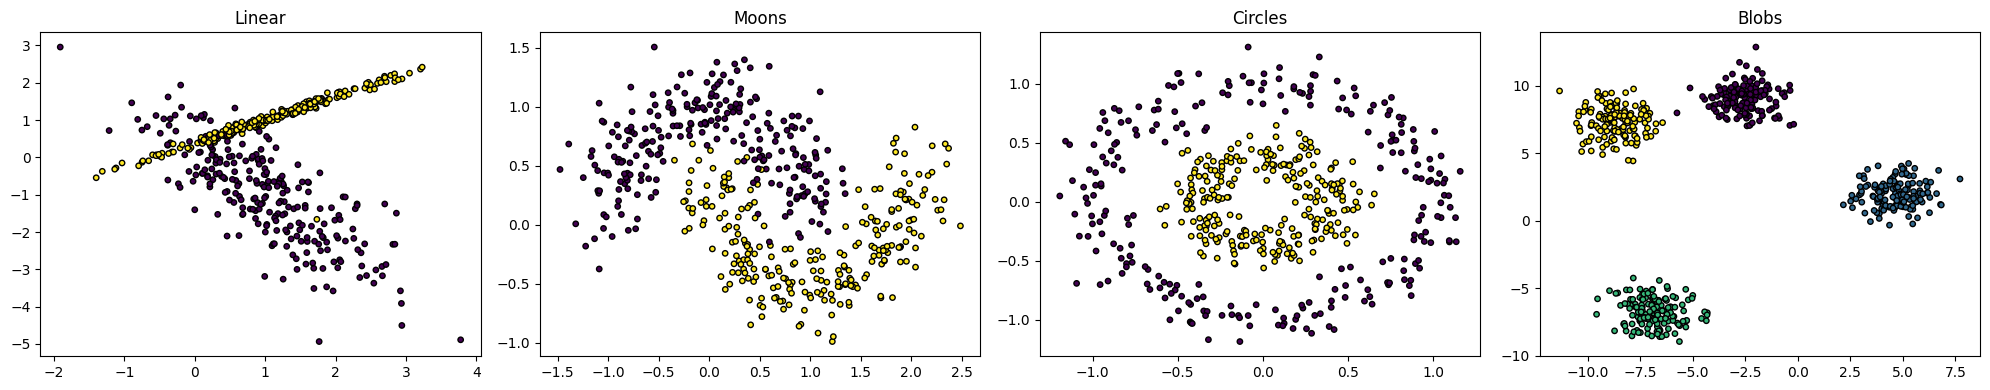

In [4]:
# Binary classification - linearly separable
# (num_samples, num_features), (num_samples,)
X_lin, y_lin = make_classification(
    n_samples=500, n_features=2, n_redundant=0, n_informative=2,
    n_clusters_per_class=1, random_state=42,
)
X_lin_train, X_lin_test, y_lin_train, y_lin_test = train_test_split(
    X_lin, y_lin, test_size=0.2, random_state=42
)

# Non-linear - moons
# (num_samples, 2), (num_samples,)
X_moon, y_moon = make_moons(n_samples=500, noise=0.2, random_state=42)
X_moon_train, X_moon_test, y_moon_train, y_moon_test = train_test_split(
    X_moon, y_moon, test_size=0.2, random_state=42
)

# Non-linear - circles
# (num_samples, 2), (num_samples,)
X_circ, y_circ = make_circles(n_samples=500, noise=0.1, factor=0.4, random_state=42)
X_circ_train, X_circ_test, y_circ_train, y_circ_test = train_test_split(
    X_circ, y_circ, test_size=0.2, random_state=42
)

# Multi-class - 4 blobs
# (num_samples, 2), (num_samples,)
X_blob, y_blob = make_blobs(n_samples=600, centers=4, n_features=2, random_state=42)
X_blob_train, X_blob_test, y_blob_train, y_blob_test = train_test_split(
    X_blob, y_blob, test_size=0.2, random_state=42
)

# Iris dataset for multi-class demos
iris = load_iris()
# (150, 4), (150,)
X_iris, y_iris = iris.data, iris.target
X_iris_train, X_iris_test, y_iris_train, y_iris_test = train_test_split(
    X_iris, y_iris, test_size=0.2, random_state=42
)

# Standardize copies for algorithms that need it
scaler = StandardScaler()
X_lin_train_s = scaler.fit_transform(X_lin_train)
X_lin_test_s = scaler.transform(X_lin_test)

scaler_m = StandardScaler()
X_moon_train_s = scaler_m.fit_transform(X_moon_train)
X_moon_test_s = scaler_m.transform(X_moon_test)

scaler_c = StandardScaler()
X_circ_train_s = scaler_c.fit_transform(X_circ_train)
X_circ_test_s = scaler_c.transform(X_circ_test)

fig, axes = plt.subplots(1, 4, figsize=(20, 4))
for ax, X, y, t in zip(
    axes,
    [X_lin, X_moon, X_circ, X_blob],
    [y_lin, y_moon, y_circ, y_blob],
    ["Linear", "Moons", "Circles", "Blobs"],
):
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap="viridis", edgecolors="k", s=15)
    ax.set_title(t)
plt.tight_layout()
plt.show()

# 1) Logistic Regression

Logistic regression models the posterior probability $P(y=1 \mid \mathbf{x})$ using a linear function passed through the **sigmoid** (logistic) function. Despite its name, it is a *classification* algorithm.

## 1.1 Binary Logistic Regression

In [5]:
class LogisticRegression:
    """Binary logistic regression via gradient descent."""

    def __init__(self, lr=0.1, num_iters=1000):
        self.lr = lr
        self.num_iters = num_iters

    @staticmethod
    def _sigmoid(z):
        # (num_samples,) -> (num_samples,)
        return 1.0 / (1.0 + np.exp(-np.clip(z, -500, 500)))

    def fit(self, X, y):
        num_samples, num_features = X.shape

        # (num_features,), scalar
        self.w = np.zeros(num_features)
        self.b = 0.0
        self.losses = []

        for _ in range(self.num_iters):
            # (num_samples, num_features) @ (num_features,) -> (num_samples,)
            z = X @ self.w + self.b
            # (num_samples,)
            y_hat = self._sigmoid(z)

            # Binary cross-entropy
            eps = 1e-15
            loss = -np.mean(y * np.log(y_hat + eps) + (1 - y) * np.log(1 - y_hat + eps))
            self.losses.append(loss)

            # (num_samples,)
            error = y_hat - y
            # (num_features, num_samples) @ (num_samples,) -> (num_features,)
            dw = X.T @ error / num_samples
            db = np.mean(error)

            self.w -= self.lr * dw
            self.b -= self.lr * db
        return self

    def predict_proba(self, X):
        # (num_samples, num_features) @ (num_features,) -> (num_samples,)
        return self._sigmoid(X @ self.w + self.b)

    def predict(self, X):
        # (num_samples,) -> (num_samples,)
        return (self.predict_proba(X) >= 0.5).astype(int)

Logistic Regression (Binary)  Accuracy: 0.8800


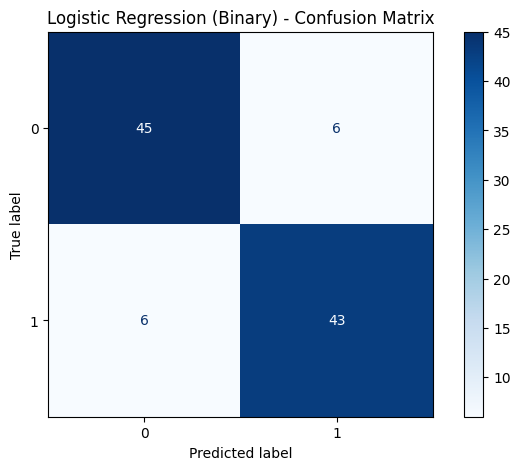

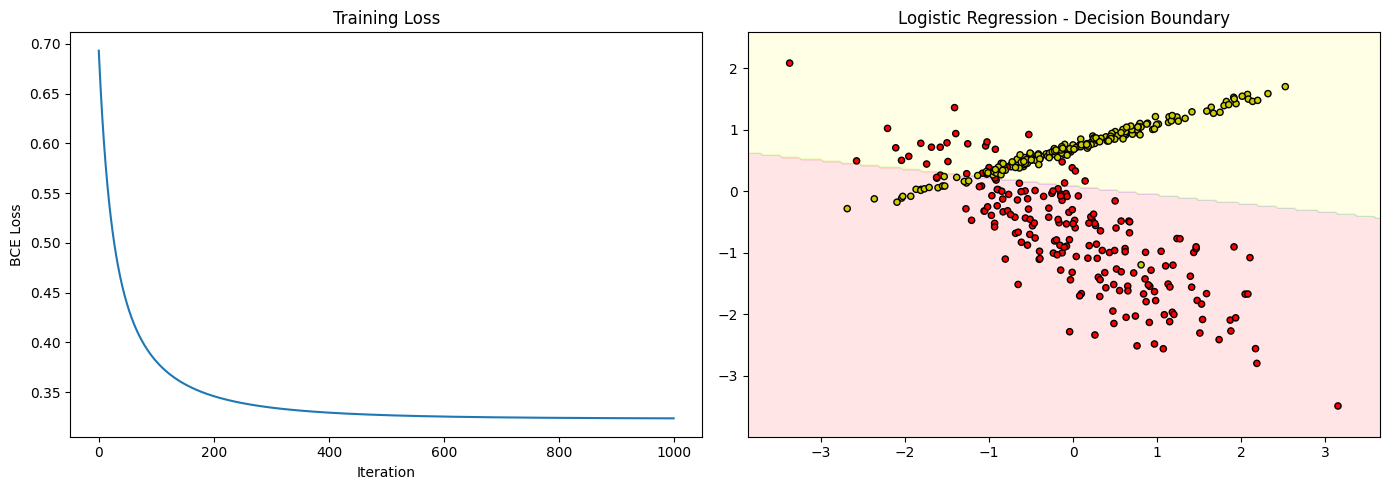

In [6]:
lr_model = LogisticRegression(lr=0.1, num_iters=1000)
lr_model.fit(X_lin_train_s, y_lin_train)

y_pred_lr = lr_model.predict(X_lin_test_s)
acc_lr = eval_classifier("Logistic Regression (Binary)", y_lin_test, y_pred_lr)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(lr_model.losses)
axes[0].set(title="Training Loss", xlabel="Iteration", ylabel="BCE Loss")
plot_decision_boundary(lr_model.predict, X_lin_train_s, y_lin_train,
                       "Logistic Regression - Decision Boundary", axes[1])
plt.tight_layout()
plt.show()

## 1.2 Multinomial Logistic Regression

Generalizes binary logistic regression to $K$ classes. The model computes a score vector $\mathbf{z} = \mathbf{X}\mathbf{W} + \mathbf{b}$ and applies the **softmax** function:

$$
P(y = k \mid \mathbf{x}) = \frac{e^{z_k}}{\sum_{j=1}^{K} e^{z_j}}
$$


In [7]:
class SoftmaxRegression:
    """Multinomial logistic regression via gradient descent."""

    def __init__(self, lr=0.1, num_iters=1000):
        self.lr = lr
        self.num_iters = num_iters

    @staticmethod
    def _softmax(z):
        # Numerically stable softmax
        # (num_samples, num_classes) -> (num_samples, num_classes)
        z_shifted = z - z.max(axis=1, keepdims=True)
        exp_z = np.exp(z_shifted)
        return exp_z / exp_z.sum(axis=1, keepdims=True)

    @staticmethod
    def _one_hot(y, num_classes):
        # (num_samples,) -> (num_samples, num_classes)
        oh = np.zeros((y.size, num_classes))
        oh[np.arange(y.size), y] = 1.0
        return oh

    def fit(self, X, y):
        num_samples, num_features = X.shape
        self.num_classes = len(np.unique(y))

        # (num_features, num_classes), (num_classes,)
        self.W = np.zeros((num_features, self.num_classes))
        self.b = np.zeros(self.num_classes)
        self.losses = []

        # (num_samples, num_classes)
        Y = self._one_hot(y, self.num_classes)

        for _ in range(self.num_iters):
            # Input: (num_samples, num_features) @ (num_features, num_classes)
            # Output: (num_samples, num_classes)
            z = X @ self.W + self.b
            # (num_samples, num_classes)
            Y_hat = self._softmax(z)

            eps = 1e-15
            # since Y is onehot encoded, only true label is 1, the rest 0
            loss = -np.mean(np.sum(Y * np.log(Y_hat + eps), axis=1))
            self.losses.append(loss)

            # (num_samples, num_classes)
            error = Y_hat - Y
            # Input: (num_features, num_samples) @ (num_samples, num_classes)
            # Output: (num_features, num_classes)
            dW = X.T @ error / num_samples
            # (num_classes,)
            db = error.mean(axis=0)

            self.W -= self.lr * dW
            self.b -= self.lr * db
        return self

    def predict_proba(self, X):
        # Input: (num_samples, num_features) @ (num_features, num_classes)
        # Output: (num_samples, num_classes)
        return self._softmax(X @ self.W + self.b)

    def predict(self, X):
        # (num_samples, num_classes) -> (num_samples,)
        return np.argmax(self.predict_proba(X), axis=1)

Softmax Regression (4-class)  Accuracy: 1.0000


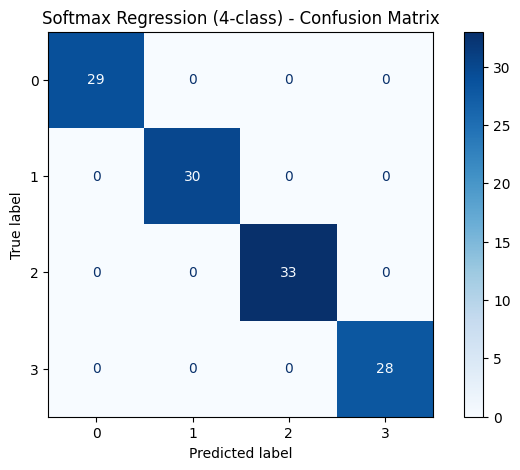

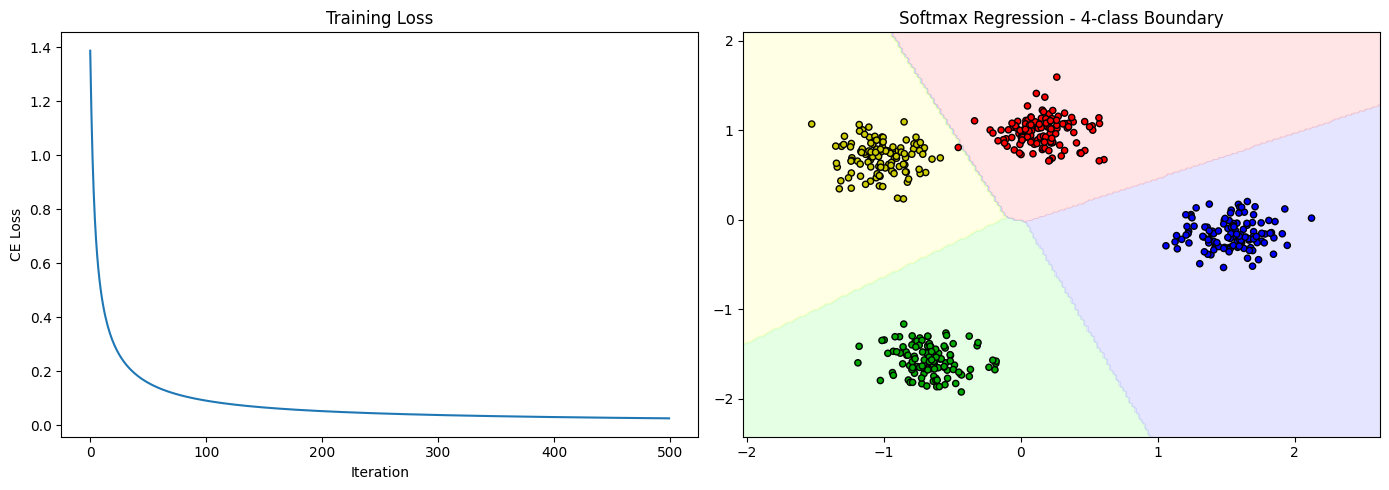

In [8]:
# Scale blobs for softmax demo
scaler_b = StandardScaler()
X_blob_train_s = scaler_b.fit_transform(X_blob_train)
X_blob_test_s = scaler_b.transform(X_blob_test)

sm_model = SoftmaxRegression(lr=0.5, num_iters=500)
sm_model.fit(X_blob_train_s, y_blob_train)

y_pred_sm = sm_model.predict(X_blob_test_s)
acc_sm = eval_classifier("Softmax Regression (4-class)", y_blob_test, y_pred_sm)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(sm_model.losses)
axes[0].set(title="Training Loss", xlabel="Iteration", ylabel="CE Loss")
plot_decision_boundary(sm_model.predict, X_blob_train_s, y_blob_train,
                       "Softmax Regression - 4-class Boundary", axes[1])
plt.tight_layout()
plt.show()

# 2) k-Nearest Neighbors (k-NN)

k-NN is a **non-parametric, instance-based** learner. It stores all training data and classifies a new point by majority vote among its $k$ closest neighbors.

In [9]:
import numpy as np
from collections import Counter

class KNNClassifier:
    """k-Nearest Neighbors classifier."""

    def __init__(self, k=5):
        self.k = k

    def fit(self, X, y):
        self.X_train = X.copy()
        self.y_train = y.copy()
        return self

    def predict(self, X):

        # Broadcasting computes differences for all pairs
        # (num_test, 1, num_features) - (1, num_train, num_features)
        # Output: (num_test, num_train, num_features)
        diff = X[:, np.newaxis, :] - self.X_train[np.newaxis, :, :]

        # (num_test, num_train)
        dists = np.sqrt(np.sum(diff ** 2, axis=2))

        # Get indices of the k nearest neighbors
        k_idx = np.argpartition(dists, self.k, axis=1)[:, :self.k]

        # Get the labels of the k nearest neighbors
        k_nearest_labels = self.y_train[k_idx]

        # Find the most common label among neighbors using pure Python
        preds = [Counter(labels).most_common(1)[0][0] for labels in k_nearest_labels]

        return np.array(preds)


k-NN (k=5) on Moons  Accuracy: 0.9600


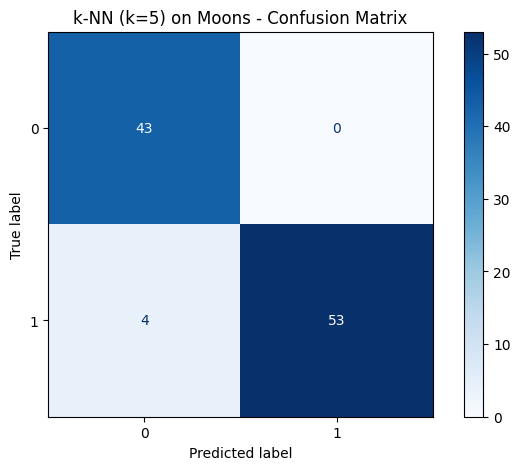

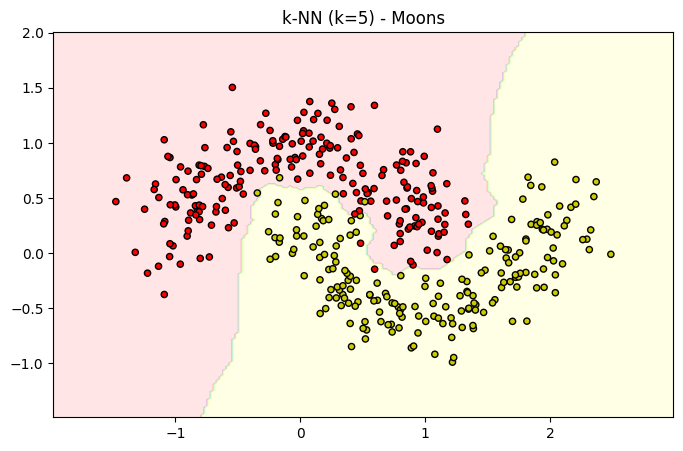

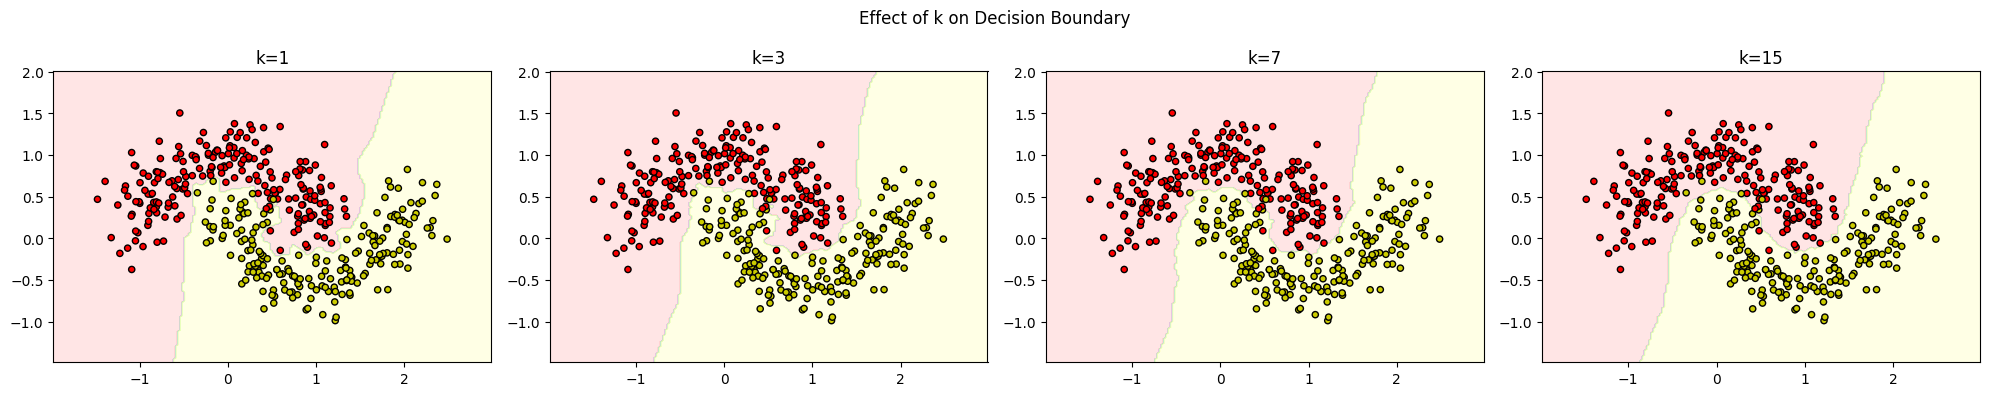

In [10]:
knn = KNNClassifier(k=5)
knn.fit(X_moon_train, y_moon_train)
y_pred_knn = knn.predict(X_moon_test)
acc_knn = eval_classifier("k-NN (k=5) on Moons", y_moon_test, y_pred_knn)

plot_decision_boundary(knn.predict, X_moon_train, y_moon_train, "k-NN (k=5) - Moons")
plt.show()

# Effect of k
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
for ax, k in zip(axes, [1, 3, 7, 15]):
    m = KNNClassifier(k=k).fit(X_moon_train, y_moon_train)
    plot_decision_boundary(m.predict, X_moon_train, y_moon_train, f"k={k}", ax)
plt.suptitle("Effect of k on Decision Boundary")
plt.tight_layout()
plt.show()

# 3) Support Vector Machines

SVMs find the **maximum-margin** separating hyperplane between classes. The key insight: the optimal boundary depends only on a small subset of training points called **support vectors**.

## 3.1 Linear SVM

We implement a **sub-gradient descent** approach to the hinge-loss formulation:

$${L}(\mathbf{w}, b) = \frac{\lambda}{2}\|\mathbf{w}\|^2 + \frac{1}{n}\sum_{i=1}^{n}\max(0, 1 - y_i(\mathbf{w}^\top \mathbf{x}_i + b))$$

In [11]:
class LinearSVM:
    """Linear SVM via sub-gradient descent on hinge loss."""

    def __init__(self, lr=0.001, lambda_reg=0.01, num_iters=1000):
        self.lr = lr
        self.lambda_reg = lambda_reg
        self.num_iters = num_iters

    def fit(self, X, y):
        num_samples, num_features = X.shape

        # Convert labels to {-1, +1}
        y_ = np.where(y <= 0, -1, 1)

        # (num_features,), scalar
        self.w = np.zeros(num_features)
        self.b = 0.0
        self.losses = []

        for _ in range(self.num_iters):

            # (num_samples,)
            # Wrong pred will always get -ve
            margins = y_ * (X @ self.w + self.b)

            # Hinge loss mask: which samples violate margin
            # flag the wrong prediction or too close to the fench
            # (num_samples,) boolean
            violated = margins < 1

            # Hinge loss value
            loss = (
                # regularization
                self.lambda_reg / 2 * np.dot(self.w, self.w) +
                # penalty=0 if margins >1.0
                np.mean(np.maximum(0, 1 - margins))
            )
            self.losses.append(loss)

            # Sub-gradients, focus on violated points
            # (num_features,)
            dw = (self.lambda_reg * self.w -
                  np.mean((violated * y_)[:, None] * X, axis=0)
            )
            db = -np.mean(violated * y_)
            self.w -= self.lr * dw
            self.b -= self.lr * db

        return self

    def decision_function(self, X):
        # (num_samples, num_features) @ (num_features,) -> (num_samples,)
        return X @ self.w + self.b

    def predict(self, X):
        # (num_samples,) -> (num_samples,) in {0, 1}
        return (self.decision_function(X) >= 0).astype(int)

Linear SVM (Hinge Loss)  Accuracy: 0.8900


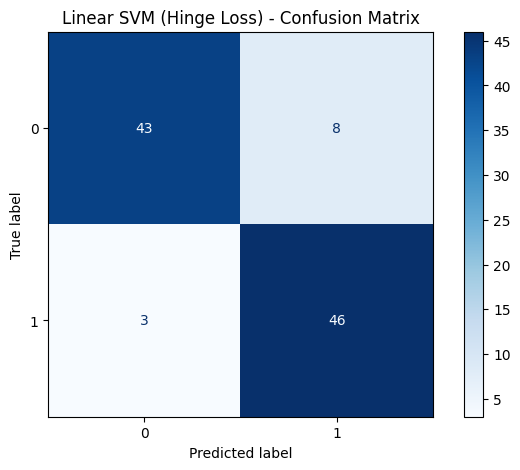

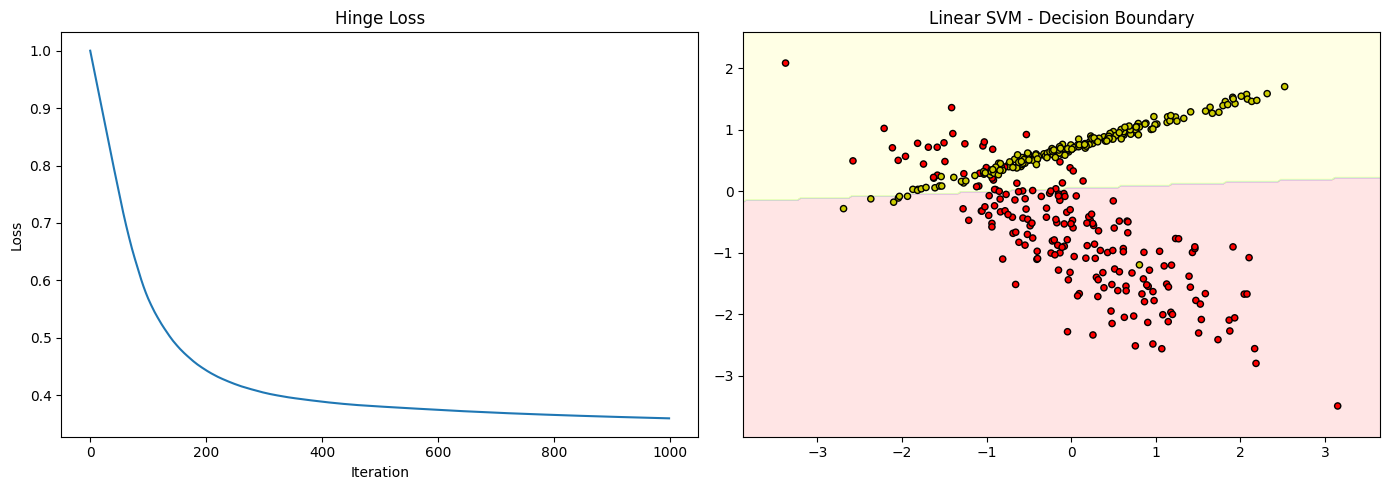

In [12]:
svm_lin = LinearSVM(lr=0.01, lambda_reg=0.01, num_iters=1000)
svm_lin.fit(X_lin_train_s, y_lin_train)
y_pred_svm = svm_lin.predict(X_lin_test_s)
acc_svm = eval_classifier("Linear SVM (Hinge Loss)", y_lin_test, y_pred_svm)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(svm_lin.losses)
axes[0].set(title="Hinge Loss", xlabel="Iteration", ylabel="Loss")
plot_decision_boundary(svm_lin.predict, X_lin_train_s, y_lin_train,
                       "Linear SVM - Decision Boundary", axes[1])
plt.tight_layout()
plt.show()

## 3.2 Kernel Trick

The key idea: instead of explicitly mapping $\mathbf{x}$ to a high-dimensional feature space $\phi(\mathbf{x})$, we compute the inner product $\langle\phi(\mathbf{x}_i), \phi(\mathbf{x}_j)\rangle$ using a **kernel function** $K(\mathbf{x}_i, \mathbf{x}_j)$.

Common kernels:
- **Linear:** $K(\mathbf{x}_i, \mathbf{x}_j) = \mathbf{x}_i^\top \mathbf{x}_j$
- **Polynomial:** $K(\mathbf{x}_i, \mathbf{x}_j) = (\gamma \mathbf{x}_i^\top \mathbf{x}_j + r)^d$
- **RBF (Gaussian):** $K(\mathbf{x}_i, \mathbf{x}_j) = \exp(-\gamma \|\mathbf{x}_i - \mathbf{x}_j\|^2)$

In [13]:
class KernelSVM:
    """SVM with kernel trick via simplified SMO."""

    def __init__(self, C=1.0, kernel="rbf", gamma=0.5, degree=3, max_passes=50, tol=1e-3):
        self.C = C
        self.kernel = kernel
        self.gamma = gamma
        self.degree = degree
        self.max_passes = max_passes
        self.tol = tol

    def _kernel_fn(self, x1, x2):
        """Compute kernel between two matrices."""
        if self.kernel == "linear":
            return x1 @ x2.T
        elif self.kernel == "rbf":
            # (n1, 1, d) - (1, n2, d) -> (n1, n2)
            if x1.ndim == 1:
                x1 = x1.reshape(1, -1)
            if x2.ndim == 1:
                x2 = x2.reshape(1, -1)
            sq_dist = np.sum((x1[:, None, :] - x2[None, :, :]) ** 2, axis=2)
            return np.exp(-self.gamma * sq_dist)
        elif self.kernel == "poly":
            return (self.gamma * x1 @ x2.T + 1) ** self.degree

    def fit(self, X, y):
        num_samples, num_features = X.shape
        y_ = np.where(y <= 0, -1.0, 1.0).astype(float)
        self.X_train = X.copy()
        self.y_train = y_.copy()

        # (num_samples, num_samples)
        K = self._kernel_fn(X, X)

        # (num_samples,)
        self.alphas = np.zeros(num_samples)
        self.b = 0.0

        passes = 0
        while passes < self.max_passes:
            num_changed = 0
            for i in range(num_samples):
                # (num_samples,) -> scalar
                E_i = float(np.sum(self.alphas * y_ * K[i, :])) + self.b - y_[i]

                if (y_[i] * E_i < -self.tol and self.alphas[i] < self.C) or \
                   (y_[i] * E_i > self.tol and self.alphas[i] > 0):

                    j = np.random.randint(0, num_samples - 1)
                    if j >= i:
                        j += 1

                    E_j = float(np.sum(self.alphas * y_ * K[j, :])) + self.b - y_[j]

                    alpha_i_old = self.alphas[i]
                    alpha_j_old = self.alphas[j]

                    # Compute bounds
                    if y_[i] != y_[j]:
                        L = max(0, self.alphas[j] - self.alphas[i])
                        H = min(self.C, self.C + self.alphas[j] - self.alphas[i])
                    else:
                        L = max(0, self.alphas[i] + self.alphas[j] - self.C)
                        H = min(self.C, self.alphas[i] + self.alphas[j])

                    if L >= H:
                        continue

                    eta = 2.0 * K[i, j] - K[i, i] - K[j, j]
                    if eta >= 0:
                        continue

                    # Update alpha_j
                    self.alphas[j] -= y_[j] * (E_i - E_j) / eta
                    self.alphas[j] = np.clip(self.alphas[j], L, H)

                    if abs(self.alphas[j] - alpha_j_old) < 1e-5:
                        continue

                    # Update alpha_i from constraint
                    self.alphas[i] += y_[i] * y_[j] * (alpha_j_old - self.alphas[j])

                    # Update bias
                    b1 = (self.b - E_i
                           - y_[i] * (self.alphas[i] - alpha_i_old) * K[i, i]
                           - y_[j] * (self.alphas[j] - alpha_j_old) * K[i, j])
                    b2 = (self.b - E_j
                           - y_[i] * (self.alphas[i] - alpha_i_old) * K[i, j]
                           - y_[j] * (self.alphas[j] - alpha_j_old) * K[j, j])

                    if 0 < self.alphas[i] < self.C:
                        self.b = b1
                    elif 0 < self.alphas[j] < self.C:
                        self.b = b2
                    else:
                        self.b = (b1 + b2) / 2.0

                    num_changed += 1

            if num_changed == 0:
                passes += 1
            else:
                passes = 0

        # Store support vectors
        sv_mask = self.alphas > 1e-5
        self.support_vectors = self.X_train[sv_mask]
        self.support_alphas = self.alphas[sv_mask]
        self.support_labels = self.y_train[sv_mask]
        return self

    def decision_function(self, X):
        # (num_test, num_sv)
        K = self._kernel_fn(X, self.support_vectors)
        # (num_sv,)
        ay = self.support_alphas * self.support_labels
        # (num_test, num_sv) @ (num_sv,) -> (num_test,)
        return (K @ ay) + self.b

    def predict(self, X):
        # (num_test,) -> (num_test,) in {0, 1}
        return (self.decision_function(X) >= 0).astype(int)

Kernel SVM (RBF) - Moons  Accuracy: 0.9600


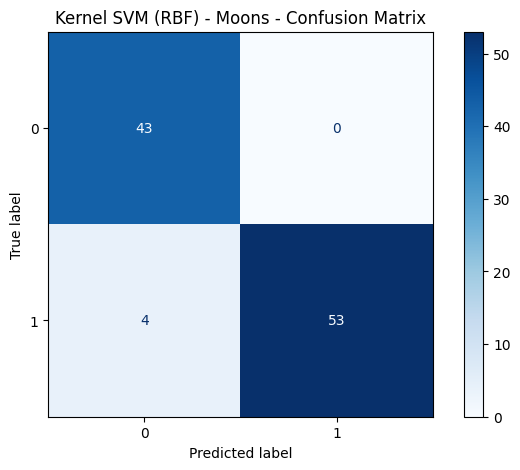

Number of support vectors: 37


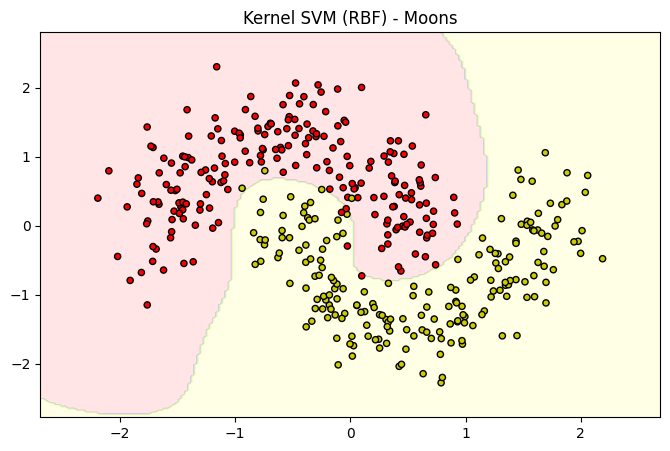

Kernel SVM (RBF) - Circles  Accuracy: 1.0000


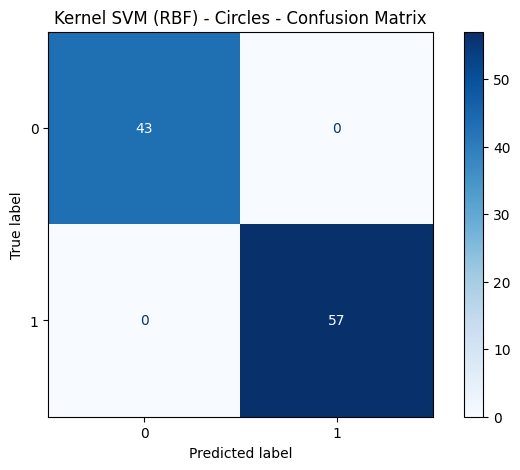

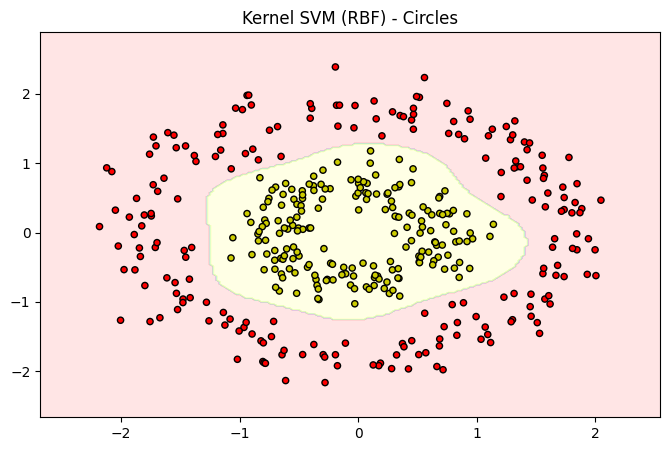

In [14]:
# RBF-kernel SVM on moons
svm_rbf = KernelSVM(C=10.0, kernel="rbf", gamma=1.0, max_passes=100)
svm_rbf.fit(X_moon_train_s, y_moon_train)
y_pred_svm_rbf = svm_rbf.predict(X_moon_test_s)
acc_svm_rbf = eval_classifier("Kernel SVM (RBF) - Moons", y_moon_test, y_pred_svm_rbf)
print(f"Number of support vectors: {len(svm_rbf.support_vectors)}")

plot_decision_boundary(svm_rbf.predict, X_moon_train_s, y_moon_train,
                       "Kernel SVM (RBF) - Moons")
plt.show()

# Circles dataset
svm_circ = KernelSVM(C=10.0, kernel="rbf", gamma=2.0, max_passes=100)
svm_circ.fit(X_circ_train_s, y_circ_train)
y_pred_svm_circ = svm_circ.predict(X_circ_test_s)
acc_svm_circ = eval_classifier("Kernel SVM (RBF) - Circles", y_circ_test, y_pred_svm_circ)

plot_decision_boundary(svm_circ.predict, X_circ_train_s, y_circ_train,
                       "Kernel SVM (RBF) - Circles")
plt.show()

# 4) Naive Bayes

Naive Bayes applies **Bayes' theorem** with the **naive** assumption that features are conditionally independent given the class:

$$
P(y \mid \mathbf{x}) \propto P(y) \prod_{j=1}^{d} P(x_j \mid y)
$$

Despite this strong (often violated) assumption, Naive Bayes works surprisingly well in practice, especially for text classification and high-dimensional data.

**Sample I/O:**
- Input: $\mathbf{X} \in \mathbb{R}^{n \times d}$, $\mathbf{y} \in \{0, \ldots, K-1\}^n$
- Output: predicted class $\hat{y} = \arg\max_k P(y=k) \prod_j P(x_j \mid y=k)$

The three variants differ in how they model $P(x_j \mid y)$:
- **Gaussian:** continuous features, $P(x_j \mid y=k) = \mathcal{N}(x_j; \mu_{jk}, \sigma_{jk}^2)$
- **Multinomial:** count features, $P(x_j \mid y=k) = \frac{N_{jk} + \alpha}{N_k + \alpha d}$ (Laplace smoothed)
- **Bernoulli:** binary features, $P(x_j \mid y=k) = p_{jk}^{x_j}(1-p_{jk})^{1-x_j}$

## 4.1 Gaussian Naive Bayes

$$P(x_j \mid y = k) = \frac{1}{\sqrt{2\pi\sigma_{jk}^2}} \exp\left(-\frac{(x_j - \mu_{jk})^2}{2\sigma_{jk}^2}\right)$$

In [15]:
class GaussianNaiveBayes:
    """Gaussian Naive Bayes classifier."""

    def fit(self, X, y):
        num_samples, num_features = X.shape
        self.classes = np.unique(y)
        num_classes = len(self.classes)

        # (num_classes, num_features) per-class mean and variance
        self.mu = np.zeros((num_classes, num_features))
        self.var = np.zeros((num_classes, num_features))
        # (num_classes,) log prior
        self.log_prior = np.zeros(num_classes)

        for idx, c in enumerate(self.classes):
            X_c = X[y == c]
            self.mu[idx] = X_c.mean(axis=0)
            self.var[idx] = X_c.var(axis=0) + 1e-9
            self.log_prior[idx] = np.log(X_c.shape[0] / num_samples)
        return self

    def _log_likelihood(self, X):
        """Compute log P(X | y=c) for each class."""
        # (num_samples, num_classes)
        log_likes = np.zeros((X.shape[0], len(self.classes)))

        for idx in range(len(self.classes)):

            # (num_features,), (num_features,)
            mu, var = self.mu[idx], self.var[idx]

            # (num_samples, num_features) -> (num_samples,)
            log_likes[:, idx] = -0.5 * np.sum(
                np.log(2 * np.pi * var) + (X - mu) ** 2 / var, axis=1
            )
        return log_likes

    def predict(self, X):
        # (num_samples, num_classes)
        log_posterior = self._log_likelihood(X) + self.log_prior

        # (num_samples,)
        return self.classes[np.argmax(log_posterior, axis=1)]

Gaussian NB - Blobs  Accuracy: 1.0000


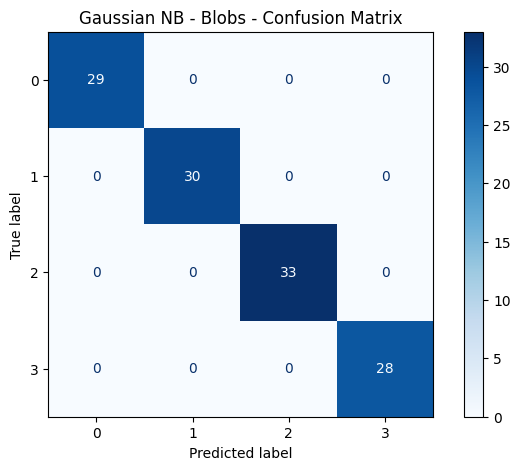

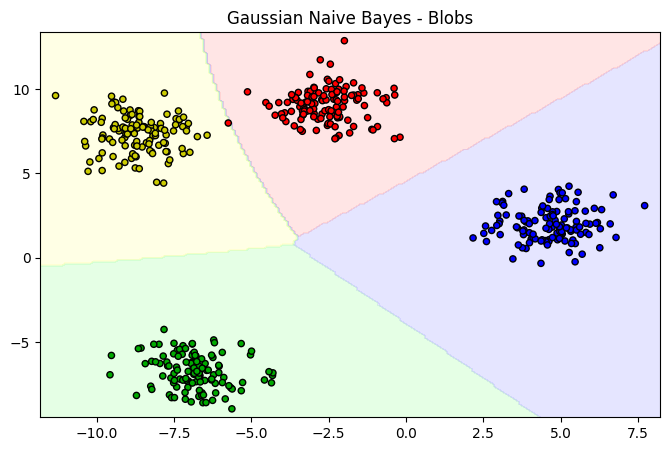

In [16]:
gnb = GaussianNaiveBayes()
gnb.fit(X_blob_train, y_blob_train)
y_pred_gnb = gnb.predict(X_blob_test)
acc_gnb = eval_classifier("Gaussian NB - Blobs", y_blob_test, y_pred_gnb)

plot_decision_boundary(gnb.predict, X_blob_train, y_blob_train,
                       "Gaussian Naive Bayes - Blobs")
plt.show()

## 4.2 Multinomial Naive Bayes

For count/frequency features (e.g., word counts in text). Uses Laplace smoothing:

$$P(x_j \mid y = k) = \frac{N_{jk} + \alpha}{N_k + \alpha d}$$

where $N_{jk}$ = total count of feature $j$ in class $k$, $N_k$ = total count of all features in class $k$.

In [17]:
class MultinomialNaiveBayes:
    """Multinomial Naive Bayes for count features."""

    def __init__(self, alpha=1.0):
        self.alpha = alpha

    def fit(self, X, y):
        num_samples, num_features = X.shape
        self.classes = np.unique(y)
        num_classes = len(self.classes)

        # (num_classes, num_features) log conditional probabilities
        self.log_prob = np.zeros((num_classes, num_features))
        # (num_classes,) log priors
        self.log_prior = np.zeros(num_classes)

        for idx, c in enumerate(self.classes):
            X_c = X[y == c]
            self.log_prior[idx] = np.log(X_c.shape[0] / num_samples)

            # (num_features,) sum of counts per feature for this class
            feature_counts = X_c.sum(axis=0) + self.alpha
            total_count = feature_counts.sum()
            self.log_prob[idx] = np.log(feature_counts / total_count)
        return self

    def predict(self, X):
        # (num_samples, num_features) @ (num_features, num_classes) -> (num_samples, num_classes)
        log_posterior = X @ self.log_prob.T + self.log_prior
        # (num_samples,)
        return self.classes[np.argmax(log_posterior, axis=1)]

Multinomial NB - Counts  Accuracy: 0.7400


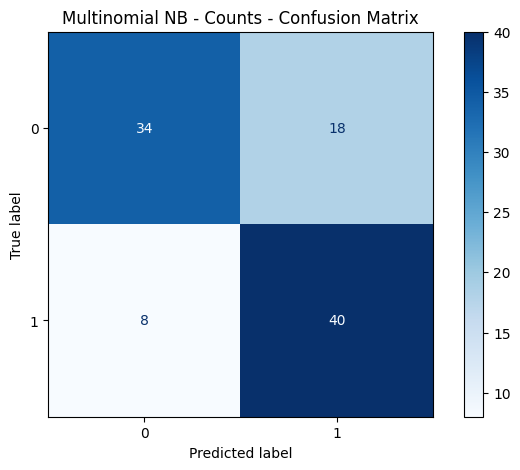

In [18]:
# Create count data by making features non-negative integers
np.random.seed(42)
X_count = np.random.randint(0, 10, size=(500, 5))
y_count = (X_count[:, 0] + X_count[:, 1] > 8).astype(int)
X_ct_train, X_ct_test, y_ct_train, y_ct_test = train_test_split(
    X_count, y_count, test_size=0.2, random_state=42
)

mnb = MultinomialNaiveBayes(alpha=1.0)
mnb.fit(X_ct_train, y_ct_train)
y_pred_mnb = mnb.predict(X_ct_test)
acc_mnb = eval_classifier("Multinomial NB - Counts", y_ct_test, y_pred_mnb)

## 4.3 Bernoulli Naive Bayes

For binary features. Explicitly models both presence and absence of a feature:

$$P(\mathbf{x} \mid y = k) = \prod_{j=1}^{d} p_{jk}^{x_j}(1 - p_{jk})^{(1-x_j)}$$

In [19]:
class BernoulliNaiveBayes:
    """Bernoulli Naive Bayes for binary features."""

    def __init__(self, alpha=1.0):
        self.alpha = alpha

    def fit(self, X, y):
        num_samples, num_features = X.shape
        self.classes = np.unique(y)
        num_classes = len(self.classes)

        # (num_classes, num_features) probability of feature=1 per class
        self.log_p = np.zeros((num_classes, num_features))
        self.log_1mp = np.zeros((num_classes, num_features))
        self.log_prior = np.zeros(num_classes)

        for idx, c in enumerate(self.classes):
            X_c = X[y == c]
            self.log_prior[idx] = np.log(X_c.shape[0] / num_samples)
            # Laplace-smoothed probability
            # (num_features,)
            p = (X_c.sum(axis=0) + self.alpha) / (X_c.shape[0] + 2 * self.alpha)
            self.log_p[idx] = np.log(p)
            self.log_1mp[idx] = np.log(1 - p)
        return self

    def predict(self, X):
        # (num_samples, num_classes)
        log_posterior = np.zeros((X.shape[0], len(self.classes)))
        for idx in range(len(self.classes)):
            # (num_samples, num_features) @ (num_features,) -> (num_samples,)
            log_posterior[:, idx] = (
                X @ self.log_p[idx]
                + (1 - X) @ self.log_1mp[idx]
                + self.log_prior[idx]
            )
        # (num_samples,)
        return self.classes[np.argmax(log_posterior, axis=1)]

Bernoulli NB - Binary  Accuracy: 1.0000


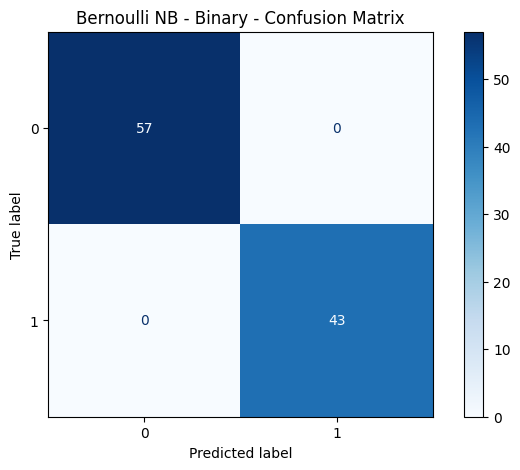

In [20]:
# Create binary data
np.random.seed(42)
X_bin = (np.random.rand(500, 6) > 0.5).astype(float)
y_bin = ((X_bin[:, 0] + X_bin[:, 1] + X_bin[:, 2]) >= 2).astype(int)
X_bn_train, X_bn_test, y_bn_train, y_bn_test = train_test_split(
    X_bin, y_bin, test_size=0.2, random_state=42
)

bnb = BernoulliNaiveBayes(alpha=1.0)
bnb.fit(X_bn_train, y_bn_train)
y_pred_bnb = bnb.predict(X_bn_test)
acc_bnb = eval_classifier("Bernoulli NB - Binary", y_bn_test, y_pred_bnb)

# 5) Decision Trees

Decision trees recursively partition the feature space using axis-aligned splits. At each node, we choose the feature and threshold that **best separates** the classes according to an impurity criterion.

## Splitting Criteria

1. **Entropy (used by ID3, C4.5):**
$$H(S) = -\sum_{k=1}^{K} p_k \log_2 p_k$$

2. **Information Gain:** $\text{IG}(S, A) = H(S) - \sum_{v} \frac{|S_v|}{|S|} H(S_v)$

3. **Gain Ratio (C4.5):** $\text{GR}(S, A) = \frac{\text{IG}(S, A)}{\text{SplitInfo}(S, A)}$

where $\text{SplitInfo}(S, A) = -\sum_v \frac{|S_v|}{|S|}\log_2 \frac{|S_v|}{|S|}$

4. **Gini Impurity (CART):**
$$\text{Gini}(S) = 1 - \sum_{k=1}^{K} p_k^2$$

In [41]:
class DecisionNode:
    """A node in the decision tree."""

    def __init__(self, feature_idx=None, threshold=None, left=None, right=None,
                 value=None, info_gain=None):
        self.feature_idx = feature_idx
        self.threshold = threshold
        self.left = left
        self.right = right
        self.value = value
        self.info_gain = info_gain

    def is_leaf(self):
        return self.value is not None

class BaseDecisionTree:
    """Base class for decision trees containing common build/predict logic."""

    def __init__(self, max_depth=10, min_samples_split=2, min_samples_leaf=1, use_midpoints=False):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.min_samples_leaf = min_samples_leaf
        self.use_midpoints = use_midpoints
        self.root = None

    def _calculate_gain(self, y, y_left, y_right):
        raise NotImplementedError("Subclasses must implement _calculate_gain.")

    def _best_split(self, X, y):
        num_samples, num_features = X.shape
        best_score = -1
        best_feature, best_threshold = None, None

        for feat_idx in range(num_features):
            sorted_vals = np.sort(np.unique(X[:, feat_idx]))
            if self.use_midpoints and len(sorted_vals) > 1:
                thresholds = (sorted_vals[:-1] + sorted_vals[1:]) / 2.0
            else:
                thresholds = sorted_vals

            for thresh in thresholds:
                left_mask = X[:, feat_idx] <= thresh
                right_mask = ~left_mask
                if left_mask.sum() < self.min_samples_leaf or right_mask.sum() < self.min_samples_leaf:
                    continue

                score = self._calculate_gain(y, y[left_mask], y[right_mask])
                if score > best_score:
                    best_score = score
                    best_feature = feat_idx
                    best_threshold = thresh

        return best_feature, best_threshold, best_score

    def _build(self, X, y, depth):
        num_samples = X.shape[0]
        num_classes = len(np.unique(y))

        if depth >= self.max_depth or num_classes == 1 or num_samples < self.min_samples_split:
            return DecisionNode(value=Counter(y).most_common(1)[0][0])

        feat_idx, threshold, score = self._best_split(X, y)

        if score <= 0 or feat_idx is None:
            return DecisionNode(value=Counter(y).most_common(1)[0][0])

        left_mask = X[:, feat_idx] <= threshold
        return DecisionNode(
            feature_idx=feat_idx, threshold=threshold,
            left=self._build(X[left_mask], y[left_mask], depth + 1),
            right=self._build(X[~left_mask], y[~left_mask], depth + 1),
            info_gain=score,
        )

    def fit(self, X, y):
        self.root = self._build(X, y, depth=0)
        return self

    def _predict_one(self, x, node):
        if node.is_leaf():
            return node.value
        if x[node.feature_idx] <= node.threshold:
            return self._predict_one(x, node.left)
        return self._predict_one(x, node.right)

    def predict(self, X):
        return np.array([self._predict_one(x, self.root) for x in X])


## 5.1 ID3 (Iterative Dichotomiser 3)

Uses **Information Gain** (entropy reduction) as the splitting criterion. Originally designed for categorical features; here adapted for continuous features using binary splits.

In [22]:
def entropy(y):
    """
    Measure of Impurity
    """

    # calculate the prob of each class based on frequency
    # (num_classes,)
    _, counts = np.unique(y, return_counts=True)
    probs = counts / counts.sum()

    # measure of surprise, lower the better
    # if prob is evenly spread then will be high
    return -np.sum(probs * np.log2(probs + 1e-15))

def information_gain(y, y_left, y_right):
    """
    Information gain from a split.
    y split into y_left and y_right
    """

    n = len(y)
    if len(y_left) == 0 or len(y_right) == 0:
        return 0

    return (
        entropy(y) -
        (len(y_left) / n) * entropy(y_left) -
        (len(y_right) / n) * entropy(y_right)
    )

In [42]:
class ID3Tree(BaseDecisionTree):
    """Decision tree using Information Gain (entropy-based ID3)."""

    def __init__(self, max_depth=10, min_samples_split=2, min_samples_leaf=1):
        super().__init__(max_depth, min_samples_split, min_samples_leaf, use_midpoints=False)

    def _calculate_gain(self, y, y_left, y_right):
        return information_gain(y, y_left, y_right)


ID3 - Moons  Accuracy: 0.9500


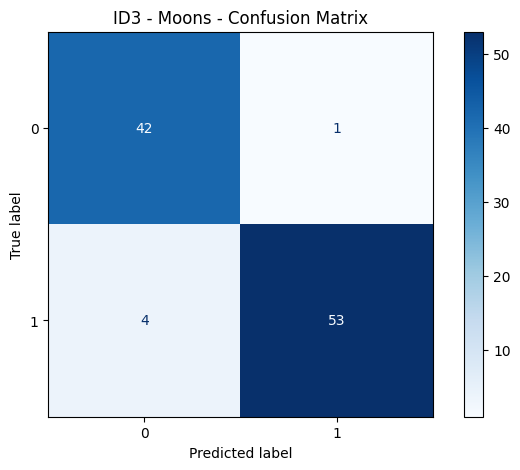

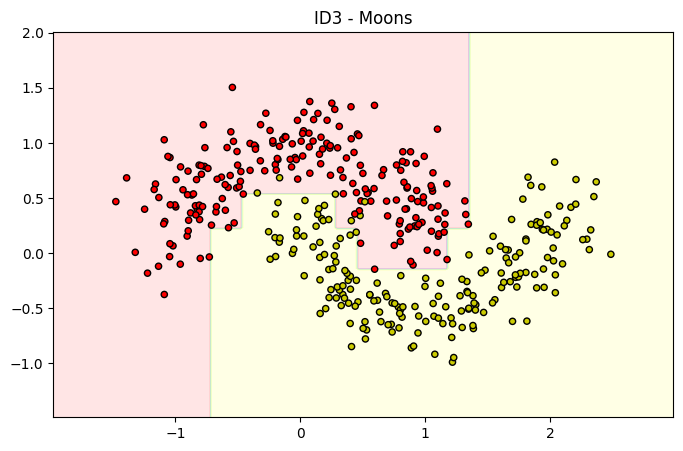

In [24]:
id3 = ID3Tree(max_depth=6, min_samples_split=5)
id3.fit(X_moon_train, y_moon_train)
y_pred_id3 = id3.predict(X_moon_test)
acc_id3 = eval_classifier("ID3 - Moons", y_moon_test, y_pred_id3)

plot_decision_boundary(id3.predict, X_moon_train, y_moon_train, "ID3 - Moons")
plt.show()

## 5.2 C4.5

Improvement over ID3: uses **Gain Ratio** to penalize features with many distinct values (which artificially inflate information gain).

$$\text{GainRatio}(S, A) = \frac{\text{IG}(S, A)}{\text{SplitInfo}(S, A)}, \quad \text{SplitInfo}(S, A) = -\sum_v \frac{|S_v|}{|S|}\log_2\frac{|S_v|}{|S|}$$

In [43]:
def gain_ratio(y, y_left, y_right):
    """Gain ratio: information gain normalized by split info."""

    n = len(y)
    ig = information_gain(y, y_left, y_right)

    # no information gain
    if ig == 0:
        return 0

    # proportion of sample that go to right/left branch
    p_l = len(y_left) / n
    p_r = len(y_right) / n

    # A 50/50 split MAXIMIZES this penalty (split_info = 1.0).
    # A highly skewed split (e.g., 1 vs 99) MINIMIZES this penalty,
    # which can artificially inflate the gain ratio.
    split_info = -(p_l * np.log2(p_l + 1e-15) + p_r * np.log2(p_r + 1e-15))

    if split_info == 0:
        return 0

    return ig / split_info


class C45Tree(BaseDecisionTree):
    """Decision tree using Gain Ratio (C4.5)."""

    def __init__(self, max_depth=10, min_samples_split=2, min_samples_leaf=1):
        super().__init__(max_depth, min_samples_split, min_samples_leaf, use_midpoints=False)

    def _calculate_gain(self, y, y_left, y_right):
        return gain_ratio(y, y_left, y_right)


C4.5 - Moons  Accuracy: 0.9500


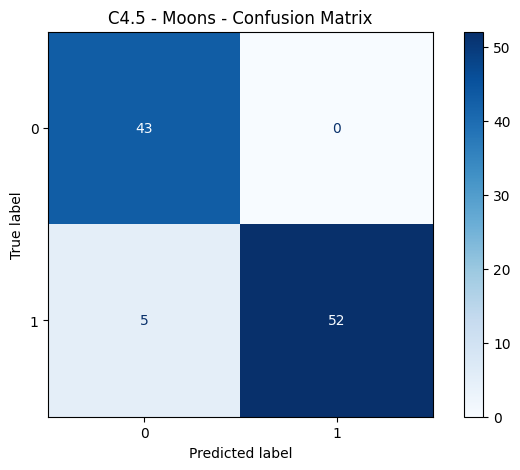

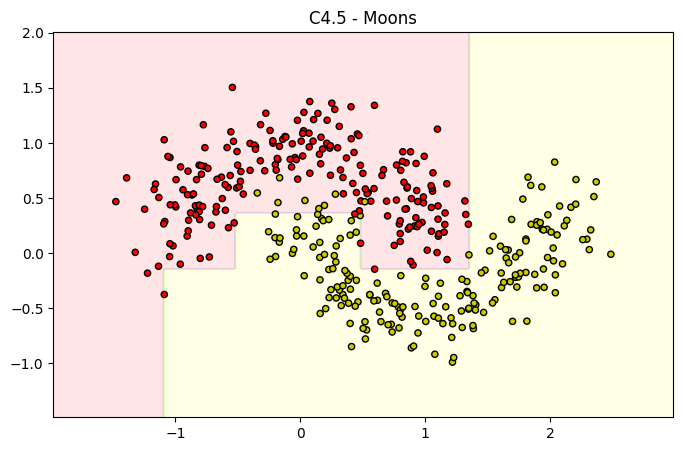

In [26]:
c45 = C45Tree(max_depth=6, min_samples_split=5)
c45.fit(X_moon_train, y_moon_train)
y_pred_c45 = c45.predict(X_moon_test)
acc_c45 = eval_classifier("C4.5 - Moons", y_moon_test, y_pred_c45)

plot_decision_boundary(c45.predict, X_moon_train, y_moon_train, "C4.5 - Moons")
plt.show()

## 5.3 CART (Classification and Regression Trees)

Uses **Gini impurity** for classification:

$$\text{Gini}(S) = 1 - \sum_{k=1}^{K} p_k^2$$

CART always produces **binary trees** and supports both classification and regression. We implement the classification variant.

In [44]:
def gini_impurity(y):
    """Compute Gini impurity."""
    _, counts = np.unique(y, return_counts=True)
    probs = counts / counts.sum()

    # faster than entropy, square vs logarithms
    return 1.0 - np.sum(probs ** 2)


def gini_gain(y, y_left, y_right):
    """Weighted Gini impurity reduction from a split."""
    n = len(y)
    if len(y_left) == 0 or len(y_right) == 0:
        return 0
    return gini_impurity(y) - (
        len(y_left) / n * gini_impurity(y_left) + len(y_right) / n * gini_impurity(y_right)
    )


class CARTTree(BaseDecisionTree):
    """CART decision tree using Gini impurity."""

    def __init__(self, max_depth=10, min_samples_split=2, min_samples_leaf=1):
        # CART traditionally evaluates midpoints between unique values
        super().__init__(max_depth, min_samples_split, min_samples_leaf, use_midpoints=True)

    def _calculate_gain(self, y, y_left, y_right):
        return gini_gain(y, y_left, y_right)


CART - Moons  Accuracy: 0.9600


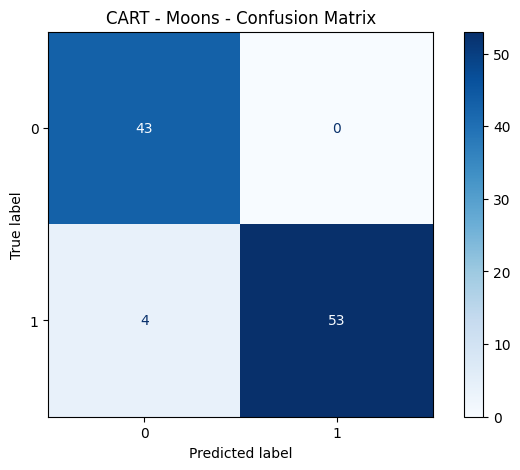

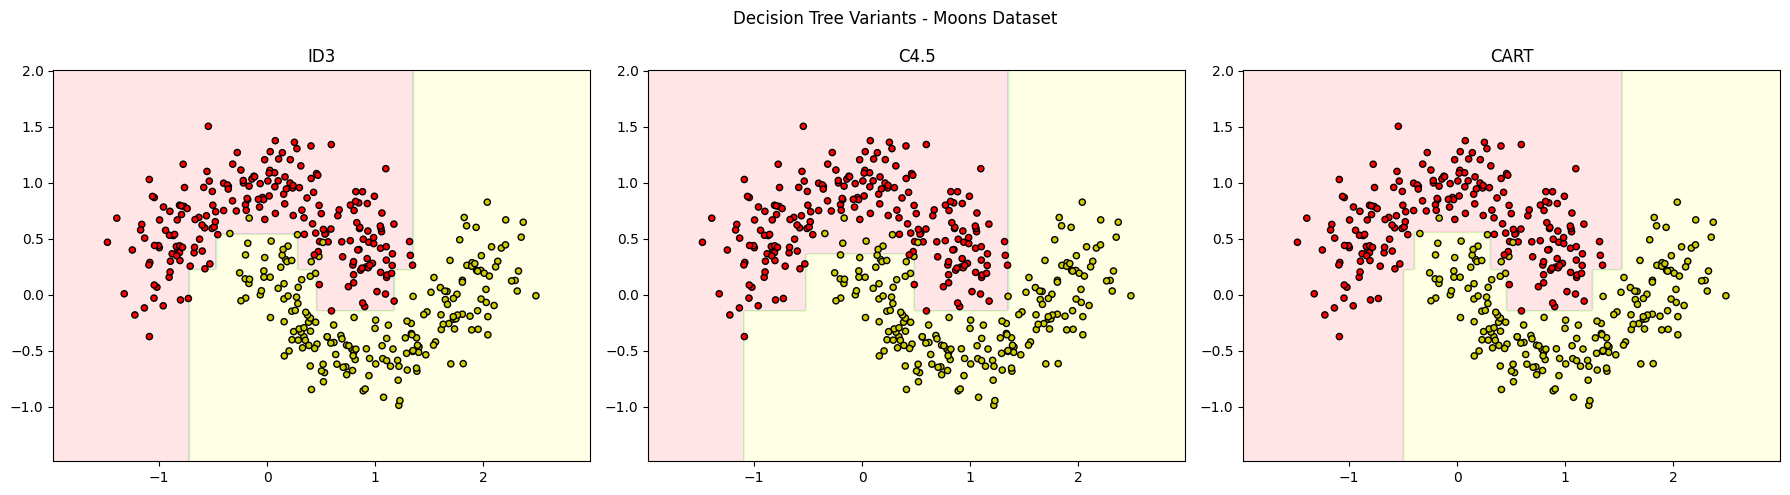

In [28]:
cart = CARTTree(max_depth=6, min_samples_split=5, min_samples_leaf=3)
cart.fit(X_moon_train, y_moon_train)
y_pred_cart = cart.predict(X_moon_test)
acc_cart = eval_classifier("CART - Moons", y_moon_test, y_pred_cart)

# Compare all three trees
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, model, name in zip(axes, [id3, c45, cart], ["ID3", "C4.5", "CART"]):
    plot_decision_boundary(model.predict, X_moon_train, y_moon_train, name, ax)
plt.suptitle("Decision Tree Variants - Moons Dataset")
plt.tight_layout()
plt.show()

## 5.4 Pruning

Pruning reduces overfitting by removing subtrees that provide little predictive power.

**Reduced Error Pruning (REP):** For each internal node, evaluate whether replacing the subtree with a leaf (majority class) improves or maintains validation accuracy. If yes, prune.

**Cost-Complexity Pruning (CCP):** Add a penalty $\alpha |T|$ for tree size. For a subtree $T_t$ at node $t$:

$$\alpha_{\text{eff}}(t) = \frac{R(t) - R(T_t)}{|T_t| - 1}$$

where $R(t)$ is the misclassification cost at node $t$ and $|T_t|$ is the number of leaves in the subtree. Prune the node with smallest $\alpha_{\text{eff}}$.

In [29]:
def count_leaves(node):
    """Count leaves in a subtree."""
    if node.is_leaf():
        return 1
    return count_leaves(node.left) + count_leaves(node.right)


def _traverse(x, node):
    """Traverse tree for a single sample."""
    if node.is_leaf():
        return node.value
    if x[node.feature_idx] <= node.threshold:
        return _traverse(x, node.left)
    return _traverse(x, node.right)


def reduced_error_prune(node, X_val, y_val):
    """Reduced Error Pruning: replace subtrees if leaf does no worse on validation."""
    if node.is_leaf() or len(y_val) == 0:
        return node

    left_mask = X_val[:, node.feature_idx] <= node.threshold
    right_mask = ~left_mask

    # Recurse first (bottom-up pruning)
    if left_mask.sum() > 0:
        node.left = reduced_error_prune(
            node.left, X_val[left_mask], y_val[left_mask]
        )
    if right_mask.sum() > 0:
        node.right = reduced_error_prune(
            node.right, X_val[right_mask], y_val[right_mask]
        )

    # Accuracy of current subtree
    preds_subtree = np.array([_traverse(x, node) for x in X_val])
    acc_subtree = np.mean(preds_subtree == y_val) if len(y_val) > 0 else 1.0

    # Accuracy if we replace this node with a leaf
    majority = Counter(y_val).most_common(1)[0][0] if len(y_val) > 0 else 0
    acc_leaf = np.mean(y_val == majority) if len(y_val) > 0 else 1.0

    # Prune if leaf is at least as good
    if acc_leaf >= acc_subtree:
        return DecisionNode(value=majority)

    return node

Deep tree   - Leaves: 15, Accuracy: 0.9600
Pruned tree - Leaves: 14, Accuracy: 0.9600


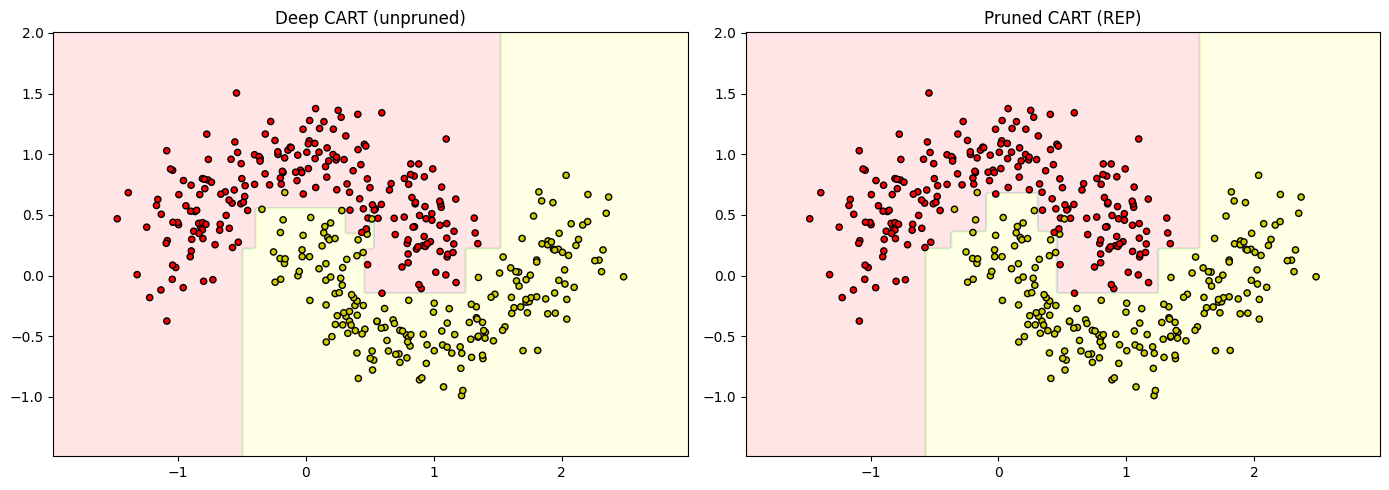

In [30]:
import copy

# Demonstrate pruning: train deep tree, then prune
cart_deep = CARTTree(max_depth=20, min_samples_split=2, min_samples_leaf=1)
cart_deep.fit(X_moon_train, y_moon_train)

# Split some training data for validation
X_prune_train, X_prune_val, y_prune_train, y_prune_val = train_test_split(
    X_moon_train, y_moon_train, test_size=0.3, random_state=42
)

cart_pruned = CARTTree(max_depth=20, min_samples_split=2, min_samples_leaf=1)
cart_pruned.fit(X_prune_train, y_prune_train)
cart_pruned.root = reduced_error_prune(
    copy.deepcopy(cart_pruned.root), X_prune_val, y_prune_val
)

y_deep = cart_deep.predict(X_moon_test)
y_pruned = cart_pruned.predict(X_moon_test)
print(f"Deep tree   - Leaves: {count_leaves(cart_deep.root)}, Accuracy: {accuracy_score(y_moon_test, y_deep):.4f}")
print(f"Pruned tree - Leaves: {count_leaves(cart_pruned.root)}, Accuracy: {accuracy_score(y_moon_test, y_pruned):.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_decision_boundary(cart_deep.predict, X_moon_train, y_moon_train, "Deep CART (unpruned)", axes[0])
plot_decision_boundary(cart_pruned.predict, X_moon_train, y_moon_train, "Pruned CART (REP)", axes[1])
plt.tight_layout()
plt.show()

# 6) Random Forests and Bagging


**Bagging** (Bootstrap AGGregatING) reduces variance by training multiple models on bootstrap samples and averaging predictions. **Random Forests** extend bagging by additionally randomizing feature subsets at each split, decorrelating the trees.

In [31]:
class RandomForestClassifier:
    """Random Forest from scratch using CART trees."""

    def __init__(self, num_trees=50, max_depth=10, min_samples_split=5,
                 max_features="sqrt", bootstrap=True):
        self.num_trees = num_trees
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.max_features = max_features
        self.bootstrap = bootstrap
        self.trees = []
        self.feature_indices = []

    def _get_num_features(self, num_features):
        if self.max_features == "sqrt":
            return max(1, int(np.sqrt(num_features)))
        elif self.max_features == "log2":
            return max(1, int(np.log2(num_features)))
        elif isinstance(self.max_features, int):
            return self.max_features
        return num_features

    def fit(self, X, y):
        num_samples, num_features = X.shape
        m = self._get_num_features(num_features)

        for _ in range(self.num_trees):

            # Each tree is based on subset of sample
            if self.bootstrap:
                idx = np.random.choice(num_samples, num_samples, replace=True)
            else:
                idx = np.arange(num_samples)

            # Each tree is based on subset of features
            feat_idx = np.random.choice(num_features, m, replace=False)
            self.feature_indices.append(feat_idx)

            tree = CARTTree(
                max_depth=self.max_depth,
                min_samples_split=self.min_samples_split,
            )
            # (num_bootstrap, m), (num_bootstrap,)
            tree.fit(X[np.ix_(idx, feat_idx)], y[idx])
            self.trees.append(tree)
        return self

    def predict(self, X):
        # (num_trees, num_samples) predictions from each tree
        all_preds = np.array([
            tree.predict(X[:, feat_idx])
            for tree, feat_idx in zip(self.trees, self.feature_indices)
        ])

        # Majority vote: (num_samples,)
        return np.array([
            Counter(all_preds[:, i]).most_common(1)[0][0]
            for i in range(X.shape[0])
        ])

Random Forest - Moons  Accuracy: 0.8700


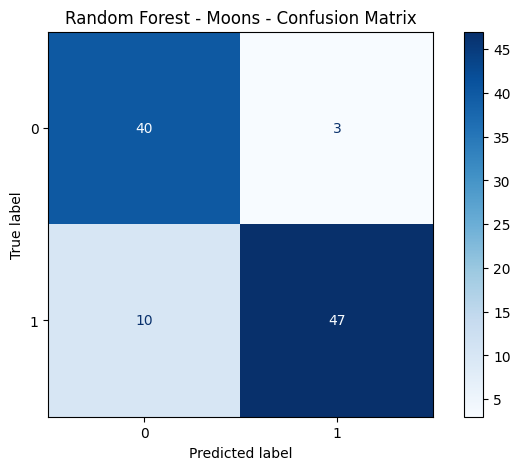

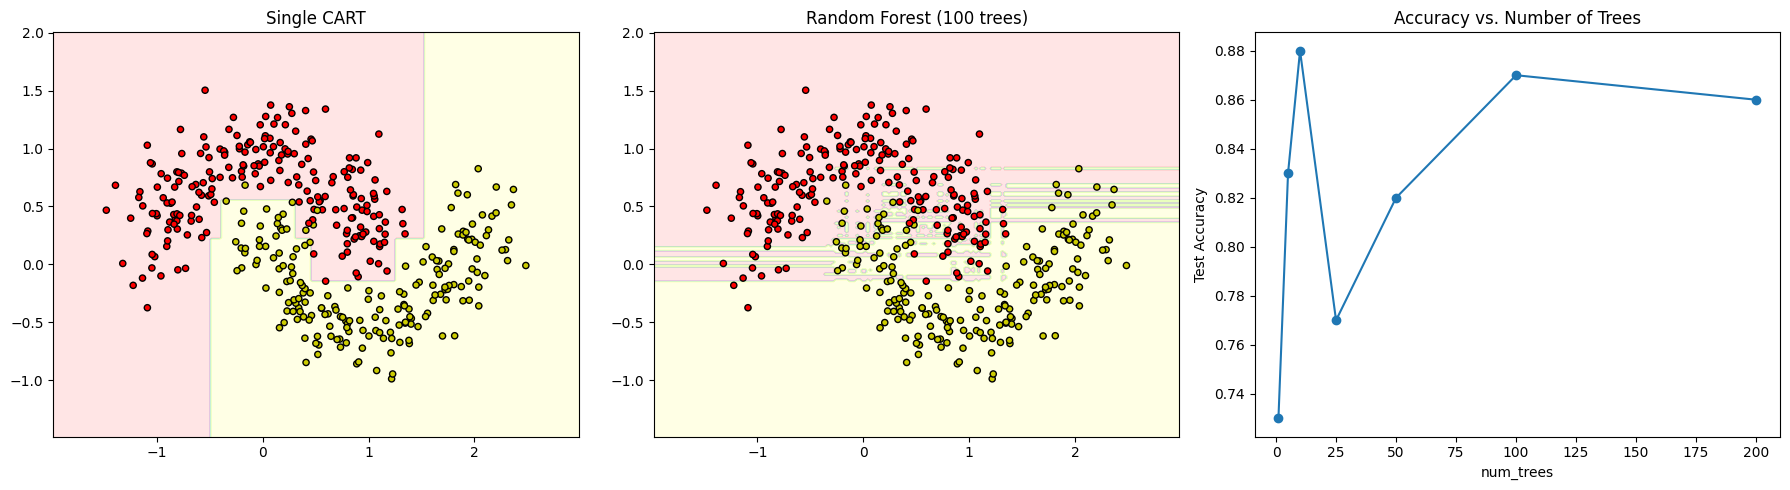

In [32]:
rf = RandomForestClassifier(num_trees=100, max_depth=8, min_samples_split=5)
rf.fit(X_moon_train, y_moon_train)
y_pred_rf = rf.predict(X_moon_test)
acc_rf = eval_classifier("Random Forest - Moons", y_moon_test, y_pred_rf)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
plot_decision_boundary(cart.predict, X_moon_train, y_moon_train, "Single CART", axes[0])
plot_decision_boundary(rf.predict, X_moon_train, y_moon_train, "Random Forest (100 trees)", axes[1])

# Effect of number of trees on accuracy
tree_counts = [1, 5, 10, 25, 50, 100, 200]
accs = []
for t in tree_counts:
    m = RandomForestClassifier(num_trees=t, max_depth=8).fit(X_moon_train, y_moon_train)
    accs.append(accuracy_score(y_moon_test, m.predict(X_moon_test)))
axes[2].plot(tree_counts, accs, "o-")
axes[2].set(title="Accuracy vs. Number of Trees", xlabel="num_trees", ylabel="Test Accuracy")
plt.tight_layout()
plt.show()

# 7) Gradient Boosting

Boosting builds an ensemble **sequentially**, where each new model corrects the errors of the previous ensemble. Unlike bagging (which reduces variance), boosting primarily reduces **bias**.

**General Gradient Boosting** fits each new tree to the negative gradient of the loss:

$$F_m(\mathbf{x}) = F_{m-1}(\mathbf{x}) + \eta \cdot h_m(\mathbf{x})$$

where $h_m$ is trained to approximate $-\nabla_{F_{m-1}} \mathcal{L}$.

## 7.1 AdaBoost

**Adaptive Boosting** assigns increasing weight to misclassified samples at each round.

**Algorithm:**
1. Initialize weights: $w_i = \frac{1}{n}$
2. For $t = 1, \ldots, T$:
   - Train weak learner $h_t$ on weighted data
   - Compute weighted error: $\epsilon_t = \sum_{i: h_t(x_i) \ne y_i} w_i$
   - Compute learner weight: $\alpha_t = \frac{1}{2}\ln\frac{1 - \epsilon_t}{\epsilon_t}$
   - Update sample weights: $w_i \leftarrow w_i \exp(-\alpha_t y_i h_t(x_i))$, then normalize

**Final prediction:** $H(\mathbf{x}) = \text{sign}\left(\sum_{t=1}^{T} \alpha_t h_t(\mathbf{x})\right)$

The weights are focusing on previous misprediction

In [33]:
class DecisionStump:
    """Depth-1 decision tree (weak learner for AdaBoost)."""

    def __init__(self):
        self.feature_idx = None
        self.threshold = None
        self.polarity = 1

    def fit(self, X, y, sample_weights):
        num_samples, num_features = X.shape
        best_err = float("inf")

        for feat_idx in range(num_features):
            thresholds = np.unique(X[:, feat_idx])
            for thresh in thresholds:
                for polarity in [1, -1]:
                    # (num_samples,) predictions in {-1, +1}
                    preds = np.ones(num_samples)
                    if polarity == 1:
                        preds[X[:, feat_idx] < thresh] = -1
                    else:
                        preds[X[:, feat_idx] >= thresh] = -1

                    # focus on the wrongly predicted label
                    err = np.sum(sample_weights[preds != y])
                    if err < best_err:
                        best_err = err
                        self.feature_idx = feat_idx
                        self.threshold = thresh
                        self.polarity = polarity
        return self

    def predict(self, X):
        # (num_samples,)
        preds = np.ones(X.shape[0])
        if self.polarity == 1:
            preds[X[:, self.feature_idx] < self.threshold] = -1
        else:
            preds[X[:, self.feature_idx] >= self.threshold] = -1
        return preds


class AdaBoostClassifier:
    """AdaBoost with decision stumps."""

    def __init__(self, num_estimators=50):
        self.num_estimators = num_estimators

    def fit(self, X, y):
        num_samples = X.shape[0]
        self.classes = np.unique(y)
        # Convert to {-1, +1}
        y_ = np.where(y == self.classes[0], -1, 1).astype(float)

        # (num_samples,) uniform weights
        w = np.full(num_samples, 1.0 / num_samples)

        self.stumps = []
        self.alphas = []

        for _ in range(self.num_estimators):
            stump = DecisionStump()

            # the learned threshold and feature are based on weight
            stump.fit(X, y_, w)

            # (num_samples,)
            preds = stump.predict(X)

            # Weighted error
            err = np.sum(w[preds != y_])
            err = np.clip(err, 1e-10, 1 - 1e-10)

            # Learner weight
            alpha = 0.5 * np.log((1 - err) / err)

            # Update sample weights
            w *= np.exp(-alpha * y_ * preds)
            w /= w.sum()

            # each tree will have own weight
            self.stumps.append(stump)
            self.alphas.append(alpha)
        return self

    def predict(self, X):

        # (num_estimators, num_samples)
        stump_preds = np.array([s.predict(X) for s in self.stumps])

        # (num_estimators,) @ (num_estimators, num_samples) -> (num_samples,)
        alphas = np.array(self.alphas)
        weighted_sum = alphas @ stump_preds

        # Map back to original classes
        return np.where(weighted_sum < 0, self.classes[0], self.classes[1])

AdaBoost - Moons  Accuracy: 0.9700


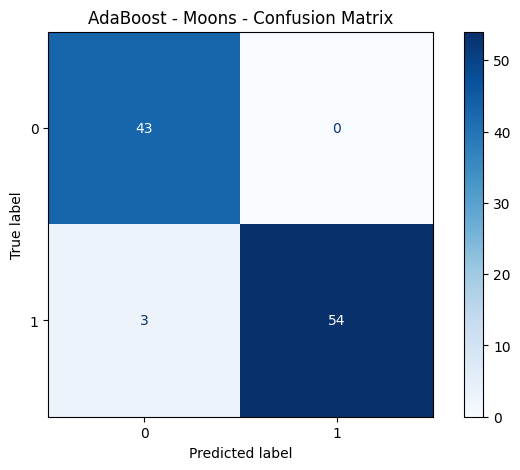

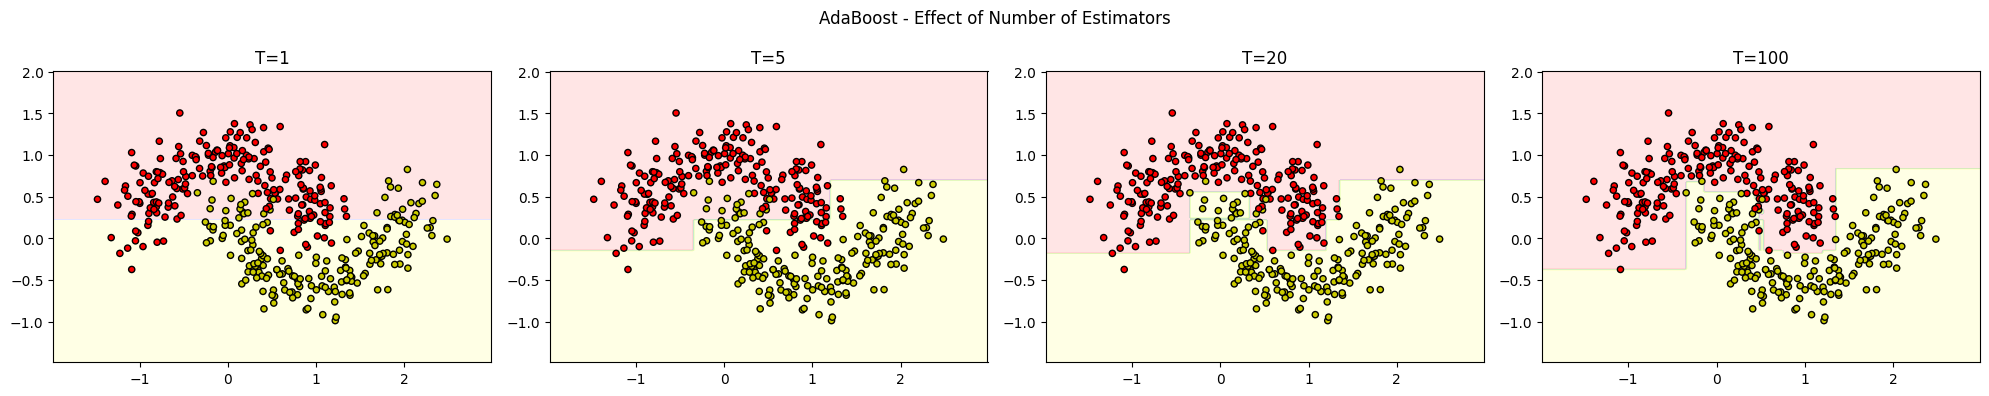

In [34]:
ada = AdaBoostClassifier(num_estimators=100)
ada.fit(X_moon_train, y_moon_train)
y_pred_ada = ada.predict(X_moon_test)
acc_ada = eval_classifier("AdaBoost - Moons", y_moon_test, y_pred_ada)

# Show effect of number of estimators
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
for ax, n_est in zip(axes, [1, 5, 20, 100]):
    m = AdaBoostClassifier(num_estimators=n_est).fit(X_moon_train, y_moon_train)
    plot_decision_boundary(m.predict, X_moon_train, y_moon_train, f"T={n_est}", ax)
plt.suptitle("AdaBoost - Effect of Number of Estimators")
plt.tight_layout()
plt.show()

## 7.2 XGBoost Internals

How XGBoost steps up conceptually from AdaBoost:

1. **Optimization Target (Weights vs. Residuals):**
   - **AdaBoost** corrects mistakes by increasing the *sample weights* of misclassified data points. The next tree tries harder on heavily weighted samples.
   - **XGBoost** (and Gradient Boosting in general) leaves weights alone. Instead, it trains the next tree to directly predict the *residual errors* (specifically, the negative gradient of the loss) made by the current ensemble.

2. **Loss Function Flexibility:**
   - **AdaBoost** is mathematically bound to minimizing exponential loss.
   - **XGBoost** uses a second-order Taylor expansion (incorporating both Gradients and Hessians). This generalized approach allows it to optimize *any* differentiable loss function (Log-Loss for classification, MSE for regression, custom business metrics, etc.).

3. **Explicit Regularization:**
   - **AdaBoost** controls overfitting primarily via the number of estimators, the learning rate, and tree depth constraints.
   - **XGBoost** introduces explicit penalization in its objective function ($\Omega(f)$). It mathematically penalizes the complexity of the trees (number of leaves) and applies L1/L2 regularization to the leaf weights themselves, yielding far more robust models.

4. **Tree Depth (Stumps vs. Deep Trees):**
   - **AdaBoost** typically uses **decision stumps** (trees with a maximum depth of 1) as its default weak learners.
   - **XGBoost** uses **deeper trees** (default depth of 6, often tuned between 3 and 10). This allows XGBoost to capture complex interactions between multiple features to calculate optimal residual corrections. You can restrict it to stumps (`max_depth=1`), but it usually performs better with deeper trees.

5. **Feature Subsampling (Column Subsampling):**
   - **AdaBoost** evaluates all available features at every split.
   - **XGBoost** borrows from Random Forests by supporting column subsampling (e.g., evaluating only a random 80% of features per tree or per node). This significantly reduces overfitting and speeds up computation.

XGBoost - Moons  Accuracy: 0.9700


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [12:12:21] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


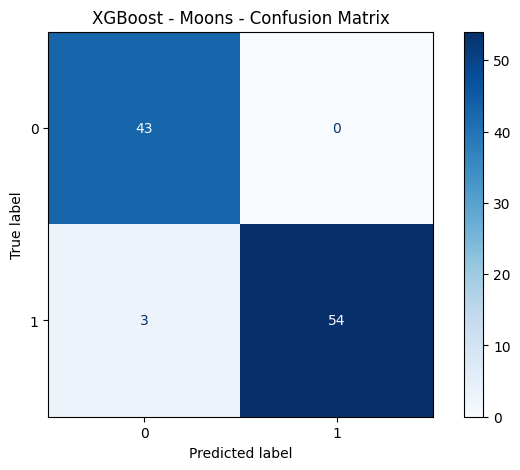

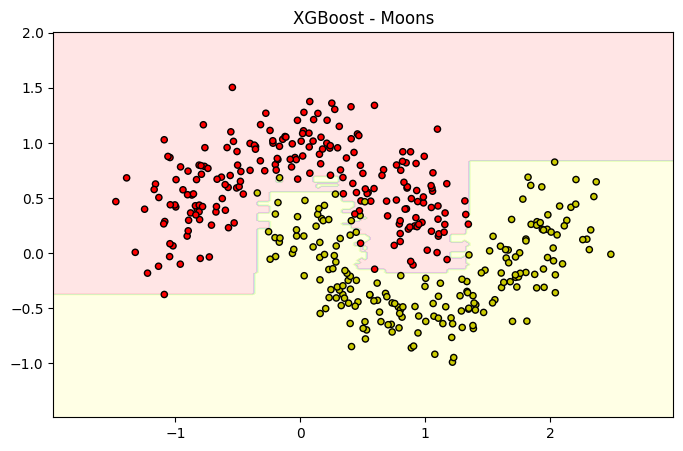

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [12:12:21] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Iris Accuracy: 1.0000


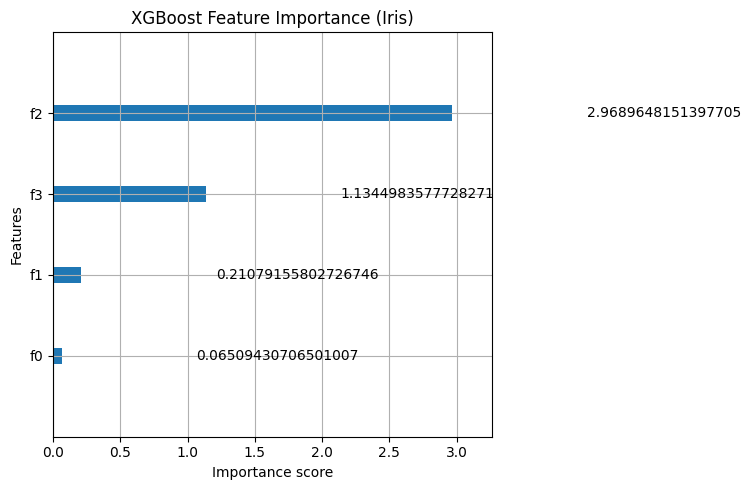

In [35]:
import xgboost as xgb

xgb_model = xgb.XGBClassifier(
    n_estimators=100, max_depth=4, learning_rate=0.1,
    reg_lambda=1.0, gamma=0.1, subsample=0.8,
    colsample_bytree=0.8, use_label_encoder=False,
    eval_metric="logloss", random_state=42,
)
xgb_model.fit(X_moon_train, y_moon_train)
y_pred_xgb = xgb_model.predict(X_moon_test)
acc_xgb = eval_classifier("XGBoost - Moons", y_moon_test, y_pred_xgb)

plot_decision_boundary(
    lambda X: xgb_model.predict(X), X_moon_train, y_moon_train,
    "XGBoost - Moons",
)
plt.show()

# Feature importance on Iris
xgb_iris = xgb.XGBClassifier(
    n_estimators=100, max_depth=4, learning_rate=0.1,
    use_label_encoder=False, eval_metric="mlogloss", random_state=42,
)
xgb_iris.fit(X_iris_train, y_iris_train)
y_pred_xgb_iris = xgb_iris.predict(X_iris_test)
print(f"XGBoost Iris Accuracy: {accuracy_score(y_iris_test, y_pred_xgb_iris):.4f}")

xgb.plot_importance(xgb_iris, importance_type="gain")
plt.title("XGBoost Feature Importance (Iris)")
plt.tight_layout()
plt.show()

## 7.3 LightGBM Internals

**LightGBM** (Light Gradient Boosting Machine) introduces two critical optimizations:

- **Leaf-Wise (Best-First) Tree Growth:** Unlike XGBoost's level-wise growth, LightGBM always splits the leaf with the highest error. This produces deeper, asymmetric trees that converge faster.
- **Gradient-Based One-Side Sampling (GOSS):** It keeps data with large errors and drops a lot of the "easy" data with small errors, drastically speeding up training.
- **Exclusive Feature Bundling (EFB):** It bundles mutually exclusive sparse features together to reduce the number of columns.
- **Histogram-Based Splitting:** Buckets continuous features into bins (like XGBoost) to speed up split finding.

- **Comparison: Level-Wise vs Leaf-Wise**

| | Level-Wise (XGBoost) | Leaf-Wise (LightGBM) |
|---|---|---|
| Growth | Balanced | Asymmetric |
| Speed | Slower per iteration | Faster per iteration |
| Overfitting | More resistant | Needs `num_leaves` tuning |
| Convergence | Slower | Faster |


LightGBM - Moons  Accuracy: 0.9700


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


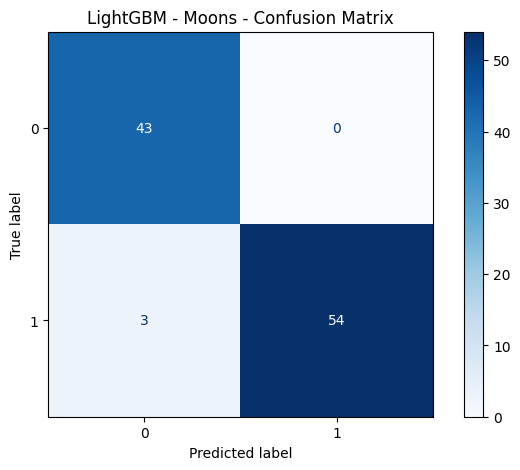

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


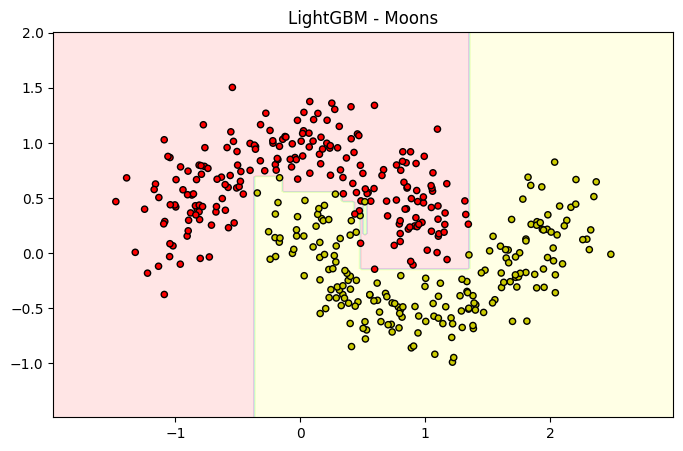

In [36]:
import lightgbm as lgb

lgb_model = lgb.LGBMClassifier(
    n_estimators=100, max_depth=-1, num_leaves=31,
    learning_rate=0.1, subsample=0.8, colsample_bytree=0.8,
    reg_lambda=1.0, random_state=42, verbose=-1,
)
lgb_model.fit(X_moon_train, y_moon_train)
y_pred_lgb = lgb_model.predict(X_moon_test)
acc_lgb = eval_classifier("LightGBM - Moons", y_moon_test, y_pred_lgb)

plot_decision_boundary(
    lambda X: lgb_model.predict(X), X_moon_train, y_moon_train,
    "LightGBM - Moons",
)
plt.show()

## 7.4 CatBoost Internals

**CatBoost** (Categorical Boosting) is designed to handle **categorical features** natively and reduce prediction bias.

- **Ordered Target Statistics:** It translates categorical data into numbers using a running historical average, preventing data leakage.
- **Ordered Boosting:** It trains trees using a random permutation sequence so that residuals are only calculated using "past" examples, avoiding bias.
- **Symmetric (Oblivious) Decision Trees:** It applies the exact same split condition across an entire depth level. This makes the trees perfectly balanced and blazing fast during prediction inference.

- **Comparison: XGBoost vs LightGBM vs CatBoost**

| Feature | XGBoost | LightGBM | CatBoost |
|---------|---------|----------|----------|
| Tree growth | Level-wise | Leaf-wise | Symmetric |
| Categorical handling | Manual encoding | Optimal split | Ordered target stats |
| Missing values | Default direction | Default direction | Ignored in splitting |
| Prediction shift | None | None | Ordered boosting |
| GPU support | Yes | Yes | Yes (native) |
| Speed (large data) | Medium | Fast | Medium |


CatBoost - Moons  Accuracy: 0.9700


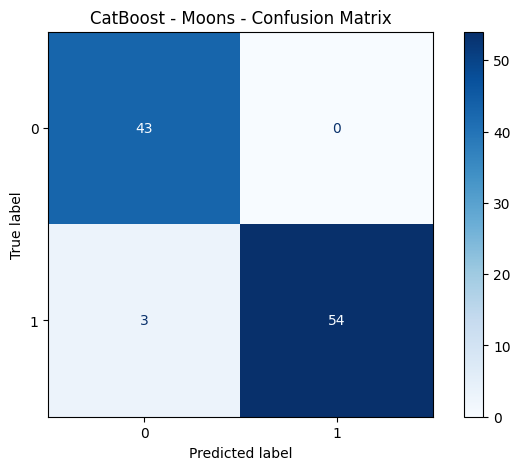

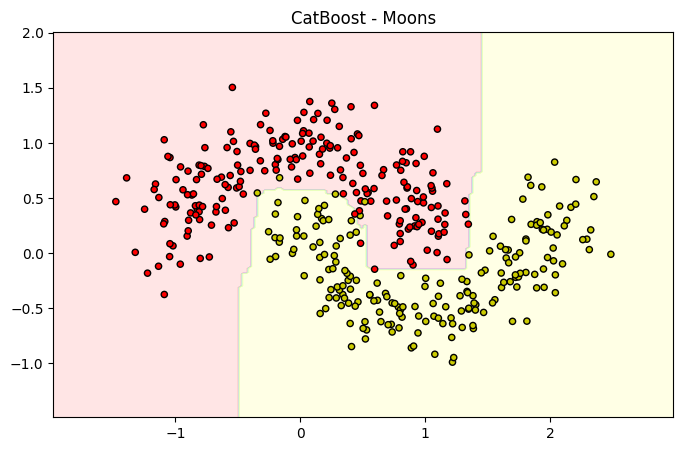

In [37]:
from catboost import CatBoostClassifier

cb_model = CatBoostClassifier(
    iterations=100, depth=4, learning_rate=0.1,
    l2_leaf_reg=3.0, random_seed=42, verbose=0,
)
cb_model.fit(X_moon_train, y_moon_train)
y_pred_cb = cb_model.predict(X_moon_test).flatten().astype(int)
acc_cb = eval_classifier("CatBoost - Moons", y_moon_test, y_pred_cb)

plot_decision_boundary(
    lambda X: cb_model.predict(X).flatten().astype(int),
    X_moon_train, y_moon_train, "CatBoost - Moons",
)
plt.show()

# 8) Final Comparison

In [38]:
# Collect results from all classifiers on the Moons dataset
results = {}

models = {
    "Logistic Regression": LogisticRegression(lr=0.1, num_iters=1000),
    "k-NN (k=5)": KNNClassifier(k=5),
    "Linear SVM": LinearSVM(lr=0.01, lambda_reg=0.01, num_iters=1000),
    "Kernel SVM (RBF)": KernelSVM(C=10.0, kernel="rbf", gamma=1.0, max_passes=100),
    "Gaussian NB": GaussianNaiveBayes(),
    "CART": CARTTree(max_depth=6, min_samples_split=5),
    "Random Forest": RandomForestClassifier(num_trees=100, max_depth=8),
    "AdaBoost": AdaBoostClassifier(num_estimators=100),
}

lib_models = {
    "XGBoost": xgb.XGBClassifier(
        n_estimators=100, max_depth=4, learning_rate=0.1,
        use_label_encoder=False, eval_metric="logloss", random_state=42,
    ),
    "LightGBM": lgb.LGBMClassifier(
        n_estimators=100, num_leaves=31, learning_rate=0.1,
        random_state=42, verbose=-1,
    ),
    "CatBoost": CatBoostClassifier(
        iterations=100, depth=4, learning_rate=0.1,
        random_seed=42, verbose=0,
    ),
}

needs_scaling = {"Logistic Regression", "Linear SVM", "Kernel SVM (RBF)"}

for name, model in models.items():
    X_tr = X_moon_train_s if name in needs_scaling else X_moon_train
    X_te = X_moon_test_s if name in needs_scaling else X_moon_test
    model.fit(X_tr, y_moon_train)
    preds = model.predict(X_te)
    results[name] = accuracy_score(y_moon_test, preds)

for name, model in lib_models.items():
    model.fit(X_moon_train, y_moon_train)
    preds = model.predict(X_moon_test)
    if hasattr(preds, "flatten"):
        preds = preds.flatten().astype(int)
    results[name] = accuracy_score(y_moon_test, preds)

sorted_results = dict(sorted(results.items(), key=lambda x: x[1], reverse=True))

print("=" * 55)
print("  CLASSIFIER COMPARISON - Moons Dataset")
print("=" * 55)
for name, acc in sorted_results.items():
    bar = chr(9608) * int(acc * 40)
    print(f"  {name:25s} {acc:.4f}  {bar}")
print("=" * 55)

  CLASSIFIER COMPARISON - Moons Dataset
  AdaBoost                  0.9700  ██████████████████████████████████████
  XGBoost                   0.9700  ██████████████████████████████████████
  LightGBM                  0.9700  ██████████████████████████████████████
  CatBoost                  0.9700  ██████████████████████████████████████
  k-NN (k=5)                0.9600  ██████████████████████████████████████
  Kernel SVM (RBF)          0.9600  ██████████████████████████████████████
  CART                      0.9600  ██████████████████████████████████████
  Random Forest             0.8800  ███████████████████████████████████
  Logistic Regression       0.8600  ██████████████████████████████████
  Gaussian NB               0.8600  ██████████████████████████████████
  Linear SVM                0.8500  ██████████████████████████████████


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [12:13:02] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


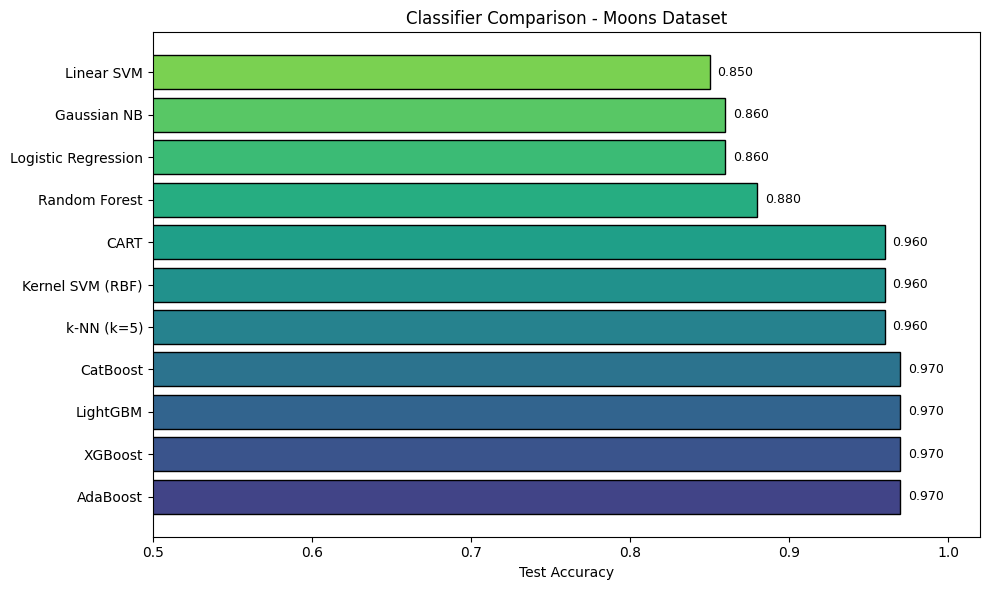

In [39]:
# Bar chart comparison
fig, ax = plt.subplots(figsize=(10, 6))
names = list(sorted_results.keys())
accs = list(sorted_results.values())
colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(names)))

bars = ax.barh(names, accs, color=colors, edgecolor="black")
ax.set_xlim(0.5, 1.02)
ax.set_xlabel("Test Accuracy")
ax.set_title("Classifier Comparison - Moons Dataset")

for bar, acc in zip(bars, accs):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height() / 2,
            f"{acc:.3f}", va="center", fontsize=9)
plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


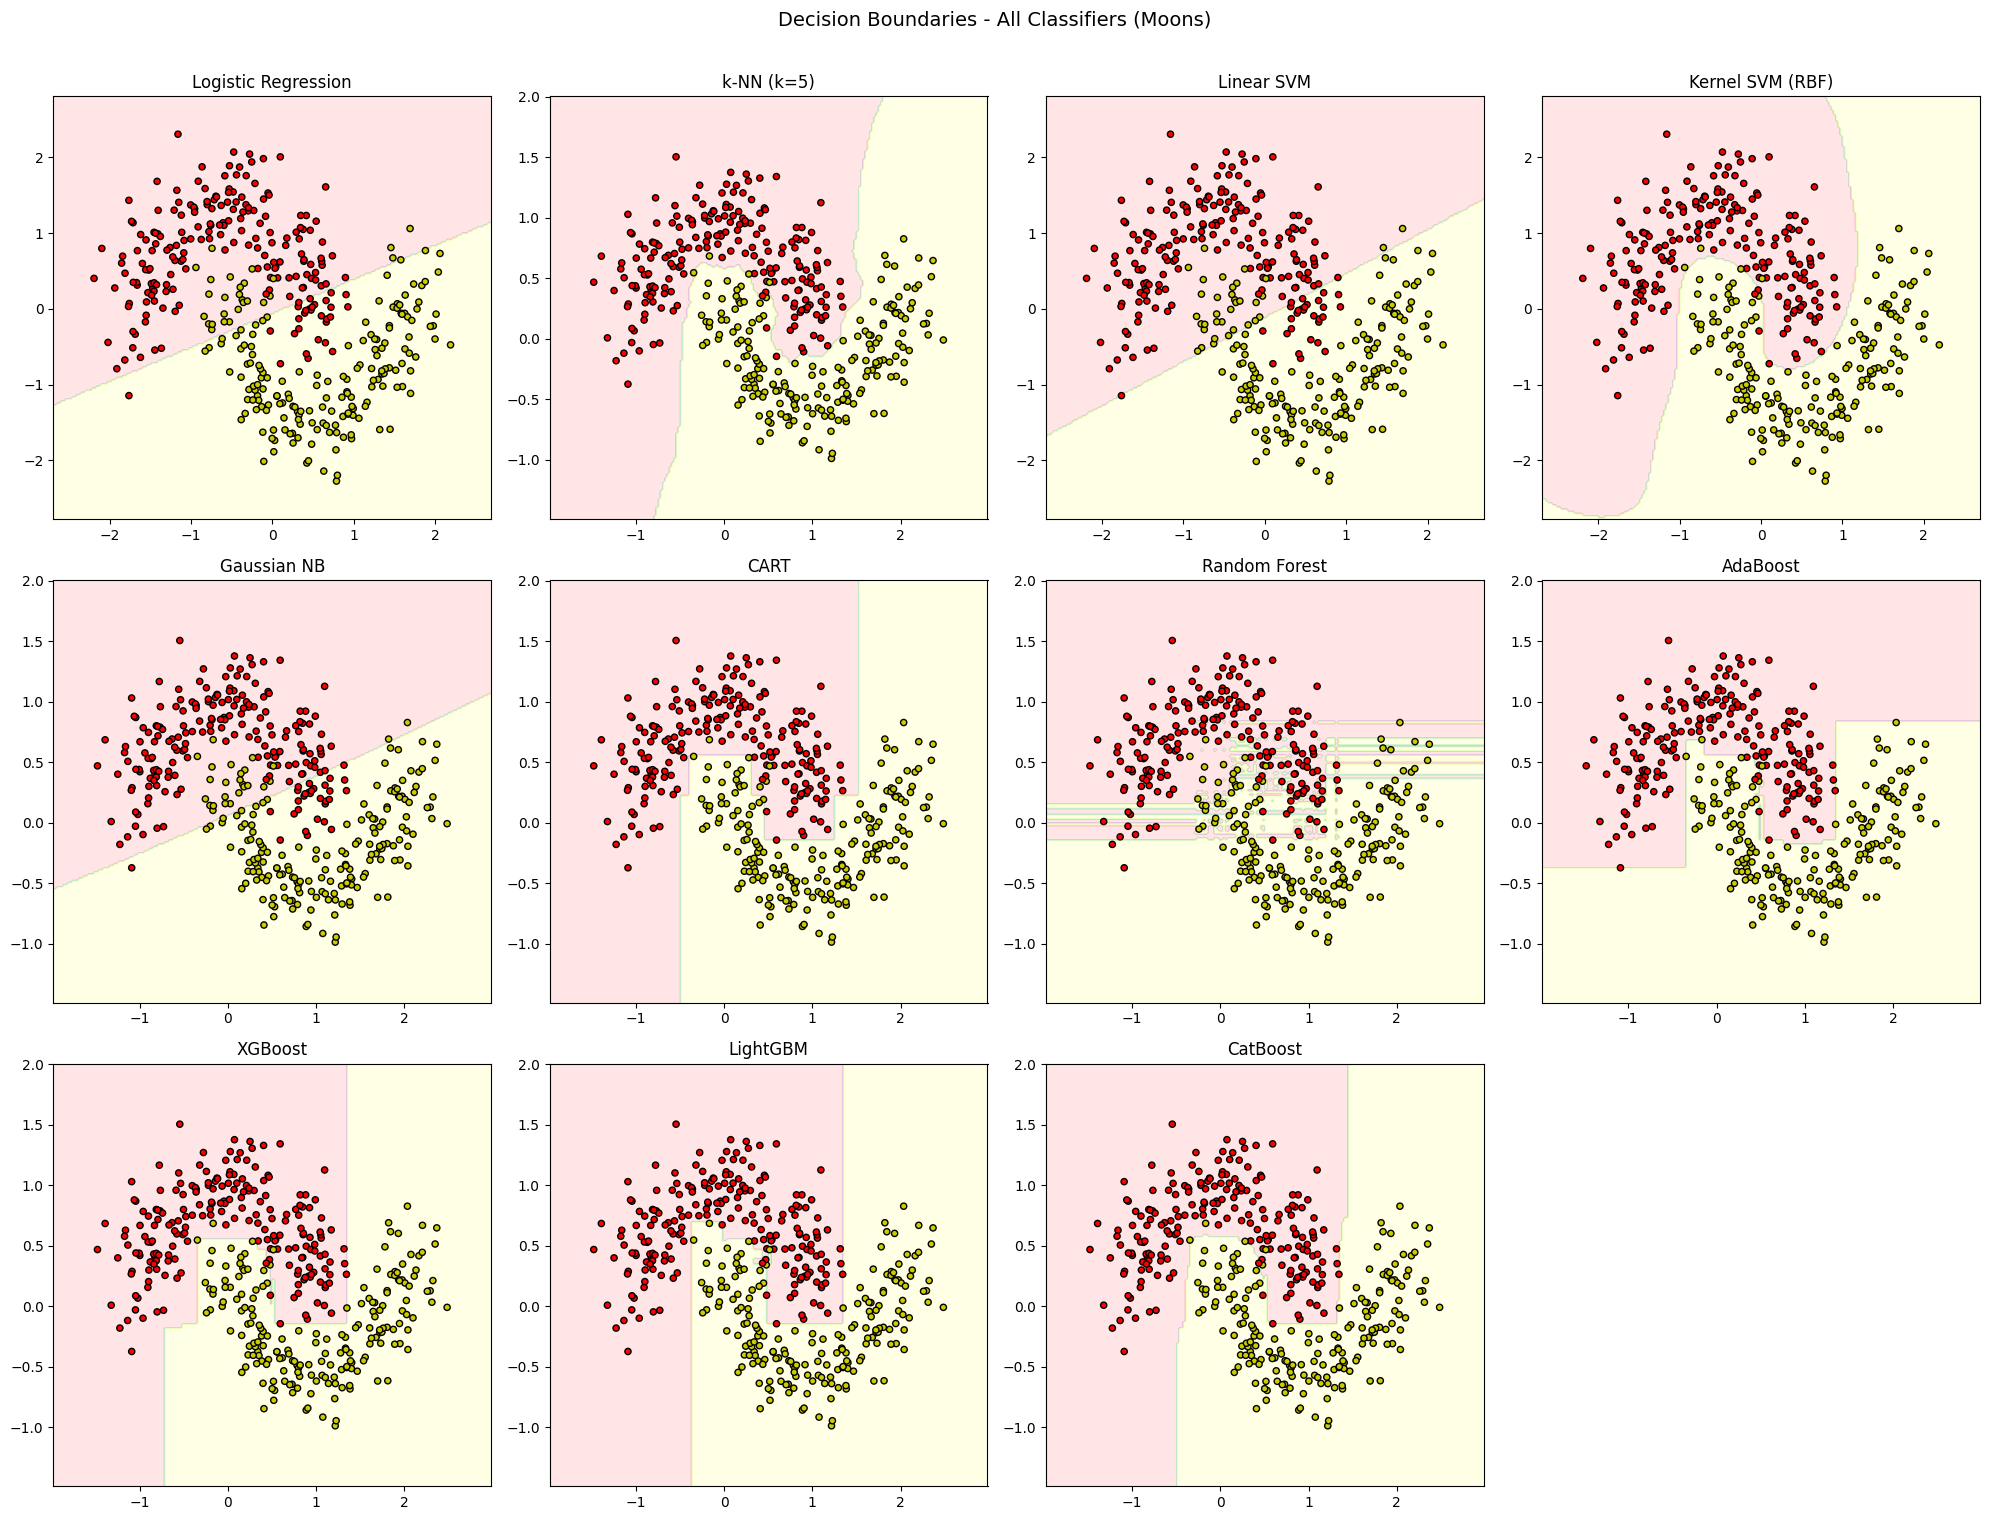

In [40]:
# Decision boundary comparison grid
all_models_2d = {}

for name, model in models.items():
    X_plot = X_moon_train_s if name in needs_scaling else X_moon_train
    all_models_2d[name] = (model, X_plot)

for name, model in lib_models.items():
    all_models_2d[name] = (model, X_moon_train)

n_models = len(all_models_2d)
ncols = 4
nrows = (n_models + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(20, 5 * nrows))
axes = axes.flatten()

for idx, (name, (model, X_plot)) in enumerate(all_models_2d.items()):
    if name == "CatBoost":
        predict_fn = lambda X, m=model: m.predict(X).flatten().astype(int)
    else:
        predict_fn = model.predict
    plot_decision_boundary(predict_fn, X_plot, y_moon_train, name, axes[idx])

for idx in range(len(all_models_2d), len(axes)):
    axes[idx].set_visible(False)

plt.suptitle("Decision Boundaries - All Classifiers (Moons)", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## Summary

| Algorithm | Type | Key Idea | Strengths | Weaknesses |
|-----------|------|----------|-----------|------------|
| Logistic Regression | Linear, parametric | Sigmoid/softmax + cross-entropy | Fast, interpretable, probabilistic | Linear boundaries only |
| k-NN | Non-parametric, instance-based | Majority vote of neighbors | Simple, no training | Slow inference, curse of dimensionality |
| SVM | Max-margin | Kernel trick, dual formulation | Effective in high-dim, kernel flexibility | Slow for large $n$, tuning-sensitive |
| Naive Bayes | Probabilistic | Conditional independence assumption | Fast, works with small data | Strong independence assumption |
| Decision Tree | Non-parametric | Recursive partitioning | Interpretable, handles mixed features | Overfitting, high variance |
| Random Forest | Ensemble (bagging) | Bootstrap + random feature subsets | Robust, low variance | Less interpretable, many trees needed |
| AdaBoost | Ensemble (boosting) | Reweight misclassified samples | Reduces bias, simple weak learners | Sensitive to noise/outliers |
| XGBoost | Gradient boosting | Regularized 2nd-order objective | State-of-the-art tabular, regularized | Hyperparameter-heavy |
| LightGBM | Gradient boosting | Leaf-wise growth, GOSS, EFB | Fast on large data, histogram-based | Risk of overfitting with small data |
| CatBoost | Gradient boosting | Ordered boosting, categorical handling | Handles categoricals, reduced leakage | Slower training than LightGBM |